# E40 · Who will win? Dynamic Bayesian poll aggregation and election forecasting

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | The 2016 US presidential polls (HuffPost Pollster: about 1,600 national and state polls, March to 7 November 2016) as used for the backtest of the Economist's forecasting model; 1976-2016 state election results; the "time for change" fundamentals series; 2013 Census state demographics - all from the Economist's public `us-potus-model` repository |
| **You will learn** | Linzer's **dynamic Bayesian forecasting model**: state opinion as **reverse random walks** anchored on a **fundamentals prior** on election day · **correlated state innovations** from a demographic/political similarity matrix · national polls as a weighted average of the states · **house, mode and population effects** · two kinds of **non-sampling error** (poll-level excess noise and a systematic polling error shared by all polls) · a **rotation** that makes the unidentified "truth vs polling error" split easy to sample · **electoral-college simulation**: win probability, tipping-point state · an honest **backtest**: forecasts as of six dates vs the actual 2016 results, interval coverage, a joint calibration check · a failure (**sampling error only**) that is certain and wrong · explaining it to everyone: 100 elections that could happen, a map of plausible elections, an honest needle, a hover map - and why "70%" is not "sure" |

## The question, in one paragraph

In the autumn of 2016 hundreds of opinion polls asked Americans whether they would vote for
Hillary Clinton or Donald Trump. Almost all of them had Clinton ahead, and many commentators
concluded she was certain to win. But a president is chosen state by state, polls are small
samples of people who may not vote, different polling companies lean in different directions,
and - the part that is easy to forget - *all* the polls can be wrong in the same direction at
the same time. We build a forecast the way the Economist and others do: start from what
history says about elections like this one, let the polls pull each state away from that
starting guess as they arrive, allow for every source of error we can name, and then play out
the election tens of thousands of times to count how often each candidate wins. Because this
is 2016, we know what happened - so we can check, honestly, what the forecast said at the time,
how wrong it was, and which ingredient made the difference between "Clinton is certain" and
"Clinton is favoured, but a Trump win would not be a shock".

## The technical version

**Linzer (2013, *JASA*)** proposed the model that most modern election forecasts descend from:
the true level of support for a candidate in each state follows a **random walk** over the
weeks of the campaign, run **backwards from election day**, where it is anchored by a prior
from a structural "fundamentals" model (economy, presidential approval, the state's past
votes). Polls are noisy measurements of the walk on the day they were taken; state polls
inform their own state, national polls a population-weighted average of all states. Days
without polls - and the weeks between today and the election - are filled in by the walk.
**Heidemanns, Gelman & Morris (2020, *Harvard Data Science Review*)**, the model behind the
Economist's 2020 forecast, added (1) state innovations and polling errors that are
**correlated** through a state-similarity matrix, (2) pollster **house effects** and
adjustments for survey **mode** and **population** (likely voters, registered voters, all
adults), and (3) explicit **non-sampling error**: extra poll-to-poll noise and a polling bias
shared by every poll in a state, correlated across states. Their code ships with the 2016 polls
for a backtest; we rebuild a smaller version of that model in PyMC and run the backtest.

**What we simplified** (so that each fit takes about 20 seconds): weekly instead of daily
time steps; a normal approximation to each poll on the logit scale (instead of a binomial
with a latent per-poll error); no adjustment for partisan non-response; the random-walk,
house-effect and excess-noise scales are *estimated* (the Economist fixed them); our own
state-similarity matrix built only from pre-2016 information; and Maine and Nebraska treated
as winner-take-all.

> **About the data.** The Economist repository's `all_polls.csv` holds the **2016** polls
> (the 2020 polls were never published there, and FiveThirtyEight's poll archive went offline
> in 2025), so this notebook forecasts 2016 and scores the forecast against the 2016 results.
> 2016 is the more instructive year anyway: the polls missed in a correlated way, and the
> forecasts that ignored that were the ones that said "99%".

In [1]:
import json
import logging
import warnings
from pathlib import Path

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Circle, Rectangle, Wedge
from scipy import stats
from scipy.special import expit, logit

from pymc_challenges import data

RANDOM_SEED = 2016
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
logging.getLogger("pymc").setLevel(logging.WARNING)
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

# Party colours for the candidates, black for what actually happened, grey for context.
DEM, REP, TRUTH, GREY, LIGHT = "#2a78d6", "#d6452a", "#222222", "#8a8a86", "#d9d9d6"
ELECTION = pd.Timestamp("2016-11-08")
START = pd.Timestamp("2016-03-01")
N_WEEKS = int(np.ceil((ELECTION - START).days / 7))        # 36 weekly steps, the last one ends on election day
WEEK_END = ELECTION - pd.to_timedelta(7 * (N_WEEKS - 1 - np.arange(N_WEEKS)), unit="D")


def stacked(da):
    """(chain, draw, ...) -> (sample, ...) NumPy array."""
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()


def date_axis(ax):
    loc = mdates.AutoDateLocator(maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

### 1.1 Election results and the electoral college

The unit of everything below is a state's **two-party vote share for Clinton**, $c/(c+t)$:
third parties are left out, as in the Economist's model. The 2012 file gives each state's
electoral votes (the 2012-2020 apportionment: 538 in total, 270 to win) and its turnout, which
gives the weight of each state in the national popular vote. The 2016 results are used **only
for scoring**, never for fitting.

In [2]:
data.describe("potus2012_states")
data.describe("potus_results_1976_2016")
s12 = data.load("potus2012_states").set_index("state")
STATES = list(s12.index)
S = len(STATES)
STATE_NAMES = s12.state_name.to_dict()
EV = s12.ev.to_numpy()
results = data.load("potus_results_1976_2016")
two_party = (results.assign(share=results.dem / (results.dem + results.rep))
             .pivot(index="state", columns="year", values="share").loc[STATES])
turnout = s12.total_count * (1 + s12.adult_pop_growth_2011_15)
W = (turnout / turnout.sum()).to_numpy()               # weight of each state in the national vote
actual = two_party[2016].to_numpy()                     # scoring only
actual_ev = int(EV[actual > 0.5].sum())
print(f"{S} states (incl. DC), {EV.sum()} electoral votes")
print(f"2012: Obama {np.dot(two_party[2012], W):.3f} of the two-party vote (weighted), "
      f"2016: Clinton {np.dot(actual, W):.3f}; Clinton's 2016 electoral votes if every state is "
      f"winner-take-all: {actual_ev}")

potus2012_states: 51 rows (50 states + DC): obama/romney percentages and vote counts, total_count, voting-age population, state_name, ev (electoral votes, 2012-2020 apportionment), adult_pop_growth_2011_15. The file has old-Mac CR line endings.
  source: 2012 presidential results by state with electoral votes and adult population growth 2011-15, GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/2012.csv
potus_results_1976_2016: One row per year x state (50 states + DC): total_votes and the Democratic, Republican and other shares of the total vote.
  source: Certified US presidential election results by state 1976-2016, as compiled in GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/potus_results_76_16.csv
51 states (incl. DC), 538 electoral votes
2012: Obama 0.520 of the two-party vote (weighted), 2016: Clinton 0.511; Clinton's 2016 electoral vote

Clinton won the two-party popular vote by about two points (51.1%) and lost the electoral
college: with Maine and Nebraska counted as winner-take-all she gets 233 electoral votes and
Trump 305 (in reality Trump won one of Maine's district votes, and seven electors defected).

### 1.2 The polls

The HuffPost Pollster file has one row per poll *question*: several populations (likely
voters, registered voters, adults, and partisan sub-samples) and question versions (with and
without third-party candidates). Following the Economist's script we keep polls whose
mid-point is on or after 1 March 2016, keep the three full populations, and keep one row per
pollster x state x mid-date, preferring likely voters and the version *with* third parties
(the smallest Clinton + Trump total). Modes are collapsed to live phone / online / other.

In [3]:
data.describe("potus2016_polls")
raw = data.load("potus2016_polls")
polls = raw[raw.population.isin(["Likely Voters", "Registered Voters", "Adults"])
            & (raw["number.of.observations"] > 1)].copy()
polls["begin"] = pd.to_datetime(polls["start.date"])
polls["end"] = pd.to_datetime(polls["end.date"])
polls["mid"] = polls.end - pd.to_timedelta((1 + (polls.end - polls.begin).dt.days) // 2, unit="D")
polls = polls[polls.mid >= START]
polls["pop_rank"] = polls.population.map({"Likely Voters": 0, "Registered Voters": 1, "Adults": 2})
polls["two"] = polls.clinton + polls.trump
polls = (polls.sort_values(["state", "mid", "pollster", "pop_rank", "two"])
         .drop_duplicates(["state", "mid", "pollster"]).reset_index(drop=True))
mode_l = polls["mode"].str.lower()
polls["mode3"] = np.where(mode_l == "internet", "online",
                          np.where(mode_l.str.contains("live phone"), "live phone", "other"))
polls["share"] = polls.clinton / polls.two                       # Clinton's two-party share
polls["n2"] = polls["number.of.observations"] * polls.two / 100  # respondents choosing one of the two
polls["y"] = logit(polls.share)
polls["se"] = 1 / np.sqrt(polls.n2 * polls.share * (1 - polls.share))   # sampling sd on the logit scale
polls["week"] = N_WEEKS - 1 - ((ELECTION - polls.mid).dt.days - 1) // 7
polls["national"] = polls.state == "--"
MODES = ["live phone", "online", "other"]
POPS = ["Likely Voters", "Registered Voters", "Adults"]
print(f"{len(polls):,} polls: {polls.national.sum()} national, {(~polls.national).sum()} state polls "
      f"in {polls[~polls.national].state.nunique()} states; {polls.pollster.nunique()} pollsters")
print("polls by mode:", polls.mode3.value_counts().to_dict())
print("by population:", polls.population.value_counts().to_dict())
print(f"respondents per poll: median {polls['number.of.observations'].median():.0f}, "
      f"max {polls['number.of.observations'].max():,.0f}")
print("state polls, fewest:", polls[~polls.national].state.value_counts().tail(6).to_dict(),
      "| no state poll at all:", sorted(set(STATES) - set(polls.state)))

potus2016_polls: 3,168 rows of 2016 Clinton-Trump polls (May 2015 - 7 Nov 2016): state (-- = national), pollster, start/end date, number.of.observations, population (Likely/Registered Voters, Adults, and partisan sub-samples), mode (Internet, Live Phone, IVR/Online, ...), percentages trump, clinton, other, undecided, johnson, mcmullin, and question.iteration (several question versions of one poll).
  source: HuffPost Pollster 2016 presidential polls, as used for the 2016 backtest of the Economist's forecasting model (Heidemanns, Gelman & Morris 2020; GitHub TheEconomist/us-potus-model, MIT licence).
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/all_polls.csv
1,620 polls: 361 national, 1259 state polls in 50 states; 250 pollsters
polls by mode: {'online': 806, 'live phone': 604, 'other': 210}
by population: {'Likely Voters': 1289, 'Registered Voters': 327, 'Adults': 4}
respondents per poll: median 799, max 70,194
state polls, fewest: {'MT': 9, 'ND':

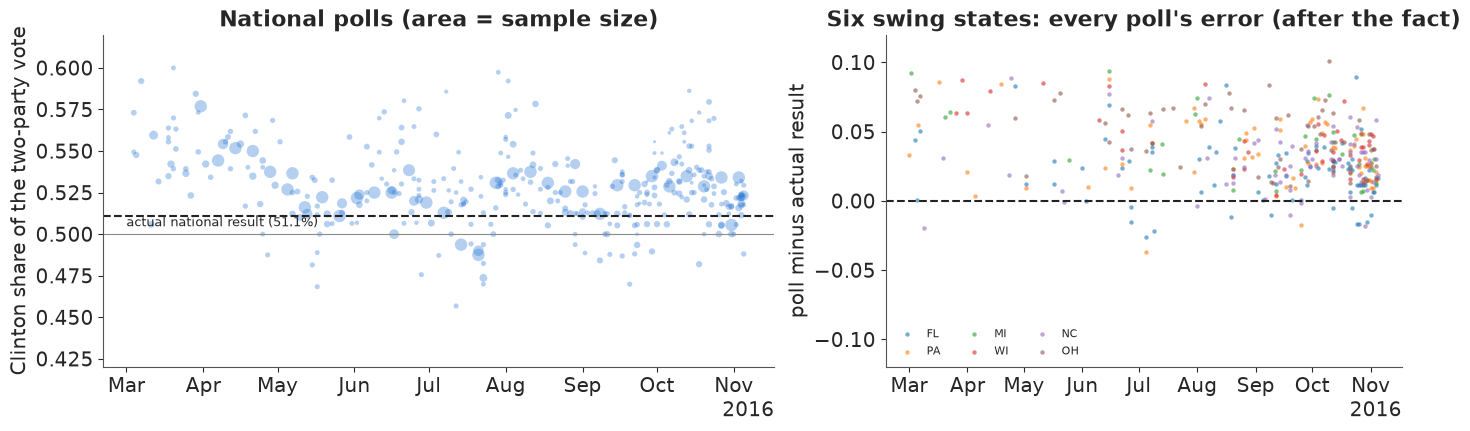

In [4]:
SWING = ["FL", "PA", "MI", "WI", "NC", "OH"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
nat = polls[polls.national]
axes[0].scatter(nat.mid, nat.share, s=np.clip(nat.n2 / 60, 4, 80), color=DEM, alpha=0.35, lw=0)
axes[0].axhline(np.dot(actual, W), color=TRUTH, lw=1.5, ls="--")
axes[0].text(START, np.dot(actual, W) - 0.006, "actual national result (51.1%)", fontsize=9)
axes[0].axhline(0.5, color=GREY, lw=0.8)
axes[0].set(ylabel="Clinton share of the two-party vote", title="National polls (area = sample size)",
            ylim=(0.42, 0.62))
date_axis(axes[0])
for s, c in zip(SWING, plt.get_cmap("tab10").colors):
    d = polls[polls.state == s]
    axes[1].scatter(d.mid, d.share - actual[STATES.index(s)], s=10, color=c, alpha=0.6, lw=0, label=s)
axes[1].axhline(0, color=TRUTH, lw=1.5, ls="--")
axes[1].set(ylabel="poll minus actual result", title="Six swing states: every poll's error (after the fact)",
            ylim=(-0.12, 0.12))
axes[1].legend(ncol=3, fontsize=8, loc="lower left")
date_axis(axes[1]);

In [5]:
late = polls[(polls.mid >= ELECTION - pd.Timedelta(days=21)) & ~polls.national]
late_err = (late.share - actual[pd.Index(STATES).get_indexer(late.state)])
print(f"state polls in the last three weeks: {len(late)}; mean error (poll - result) "
      f"{100 * late_err.mean():+.1f} points of two-party share, {100 * (late_err > 0).mean():.0f}% overstated Clinton")
nat_late = polls[(polls.mid >= ELECTION - pd.Timedelta(days=21)) & polls.national]
print(f"national polls in the last three weeks: {len(nat_late)}, mean Clinton share {nat_late.share.mean():.3f} "
      f"vs actual {np.dot(actual, W):.3f}")

state polls in the last three weeks: 477; mean error (poll - result) +2.0 points of two-party share, 76% overstated Clinton
national polls in the last three weeks: 57, mean Clinton share 0.524 vs actual 0.511


Most national polls put Clinton between 50% and 56% of the two-party vote, with a dip in
May-July and a bounce after the conventions; the result (dashed, 51.1%) sits below most of the
late polls, whose average was 52.4%. In the swing states the errors (right) are overwhelmingly
positive - the polls overstated Clinton - and they did so *together*: in the last three weeks
three state polls in four overstated her, by about 2 points of two-party share on average. That
is the pattern the rest of the notebook is about. A single poll's error
is partly random (sampling), but a shared error does not average away however many polls you
take (Kennedy et al. 2018, the AAPOR evaluation of the 2016 polls).

> **In plain words:** there were hundreds of polls, most of them showed Clinton ahead, and in
> the key Midwestern states most of them were too kind to her by a similar amount. Averaging
> many polls cancels their random wobbles, but not an error they all share.

### 1.3 Before any poll: the fundamentals prior

Structural models predict the incumbent party's share of the two-party vote from a few
numbers known in the summer. The Economist's script uses Abramowitz's "time for change"
variables: June net approval of the sitting president and second-quarter GDP growth. We fit
the same regression on 1948-2012 and predict 2016 (Obama's June approval +4, Q2 growth 1.1%),
with its **predictive** standard deviation. Each state's prior is that national figure plus
the state's 2012 lean (its Obama share minus the national Obama share): a "uniform swing".
(We use the Q2 growth figure stored in the repository; the first official estimate published
in the summer of 2016 may have differed slightly.)

In [6]:
data.describe("abramowitz_fundamentals")
ab = data.load("abramowitz_fundamentals")
train = ab[ab.year < 2016]
X = np.column_stack([np.ones(len(train)), train.juneapp, train.q2gdp])
beta, *_ = np.linalg.lstsq(X, train.incvote, rcond=None)
resid_sd = np.sqrt(np.sum((train.incvote - X @ beta) ** 2) / (len(train) - 3))
x16 = np.array([1.0, *ab.loc[ab.year == 2016, ["juneapp", "q2gdp"]].to_numpy()[0]])
fund_mean = float(x16 @ beta) / 100
fund_sd = float(resid_sd * np.sqrt(1 + x16 @ np.linalg.inv(X.T @ X) @ x16)) / 100
lean12 = (two_party[2012] - np.dot(two_party[2012], W)).to_numpy()
prior_share = fund_mean + lean12
prior_logit = logit(prior_share)
print(f"{len(train)} elections 1948-2012; incvote = {beta[0]:.1f} + {beta[1]:.3f} x June approval "
      f"+ {beta[2]:.2f} x Q2 GDP growth, residual sd {resid_sd:.1f} points")
print(f"2016 fundamentals: Democratic two-party share {fund_mean:.3f}, predictive sd {fund_sd:.3f}")
print(f"prior leaders: Clinton ahead in {np.sum(prior_share > 0.5)} states worth {EV[prior_share > 0.5].sum()} "
      f"electoral votes")

abramowitz_fundamentals: One row per election year: incumbent-party share of the two-party vote (incvote), June net presidential approval (juneapp), second-quarter annualised GDP growth (q2gdp) and other columns.
  source: Inputs of Abramowitz's 'time for change' fundamentals model 1948-2016, as compiled in GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/abramowitz_data.csv
17 elections 1948-2012; incvote = 49.6 + 0.139 x June approval + 0.45 x Q2 GDP growth, residual sd 2.8 points
2016 fundamentals: Democratic two-party share 0.506, predictive sd 0.029
prior leaders: Clinton ahead in 26 states worth 303 electoral votes


History alone makes 2016 a toss-up: about 50.6% for the Democrats with a predictive standard
deviation of about 2.9 points (17 elections are not many). A uniform swing from 2012 gives
Clinton the states Obama won except Florida: 303 electoral votes.

### 1.4 How states move together: a similarity matrix

If Clinton is doing better than expected in Wisconsin, she is probably doing better in
Michigan too, and a polling error that hits one Midwestern state probably hits its
neighbours. The Economist encodes this in a state correlation matrix built from how similar
states are: their past votes, race and education make-up, urbanicity and religiosity. We
follow their recipe, using only information available before 2016: scale each variable to
[0, 1] across states, correlate the *states* across the variables, set negative correlations
to zero, mix with a matrix of ones (`0.75 C + 0.25`) so that every pair shares some national
component, and repair it to be positive definite. (Their released matrix used the 2016
results, which would leak the answer into a 2016 backtest.)

In [7]:
for name in ["acs2013_states", "state_urbanicity", "state_white_evangelical"]:
    data.describe(name)
acs = data.load("acs2013_states").dropna(subset=["state"]).set_index("state")
urb = data.load("state_urbanicity").set_index("state")
evang = data.load("state_white_evangelical").set_index("state")
features = (pd.DataFrame({"dem_2008": two_party[2008], "dem_2012": two_party[2012]})
            .join(acs[["white_pct", "black_pct", "hisp_other_pct", "college_pct", "wwc_pct", "median_age"]])
            .join(urb[["average_log_pop_within_5_miles"]]).join(evang).loc[STATES])
assert not features.isna().any().any()
scaled = (features - features.min()) / (features.max() - features.min())
C = np.corrcoef(scaled.to_numpy())
C[C < 0] = 0
C = 0.75 * C + 0.25
eigval, eigvec = np.linalg.eigh(C)
print(f"{features.shape[1]} variables; smallest eigenvalue before repair {eigval.min():.2f}")
C = eigvec @ np.diag(np.clip(eigval, 1e-3, None)) @ eigvec.T
C = C / np.sqrt(np.outer(np.diag(C), np.diag(C)))
# The Economist's base covariance: sd 0.07 per state, 0.9 x the correlation off the diagonal.
Sigma0 = 0.07**2 * (0.9 + 0.1 * np.eye(S)) * C
SIGMA_UNIT = Sigma0 / (W @ Sigma0 @ W)      # rescaled so the NATIONAL (weighted) sd is 1
L_UNIT = np.linalg.cholesky(SIGMA_UNIT)
state_sd_unit = np.sqrt(np.diag(SIGMA_UNIT))
print(f"with a national sd of 1, each state's sd is {np.median(state_sd_unit):.2f}")
offdiag = C[np.triu_indices(S, 1)]
print(f"pairwise correlations: median {np.median(offdiag):.2f}, 5-95% {np.quantile(offdiag, 0.05):.2f}-"
      f"{np.quantile(offdiag, 0.95):.2f}")

acs2013_states: 51 rows: population, shares white, Black, Hispanic/other, college-educated, white working class (wwc_pct), median age, population density.
  source: US Census Bureau American Community Survey (2013), state summaries compiled in GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/acs_2013_variables.csv
state_urbanicity: 51 rows: state_name, pop, average_log_pop_within_5_miles, state.
  source: State urbanicity index (average log population within 5 miles of a resident), compiled in GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/urbanicity_index.csv
state_white_evangelical: 51 rows: state, pct_white_evangel.
  source: Share of white evangelical Christians by state, compiled in GitHub TheEconomist/us-potus-model.
  url:    https://raw.githubusercontent.com/TheEconomist/us-potus-model/master/data/white_evangel_pct.csv
10 variables; sma

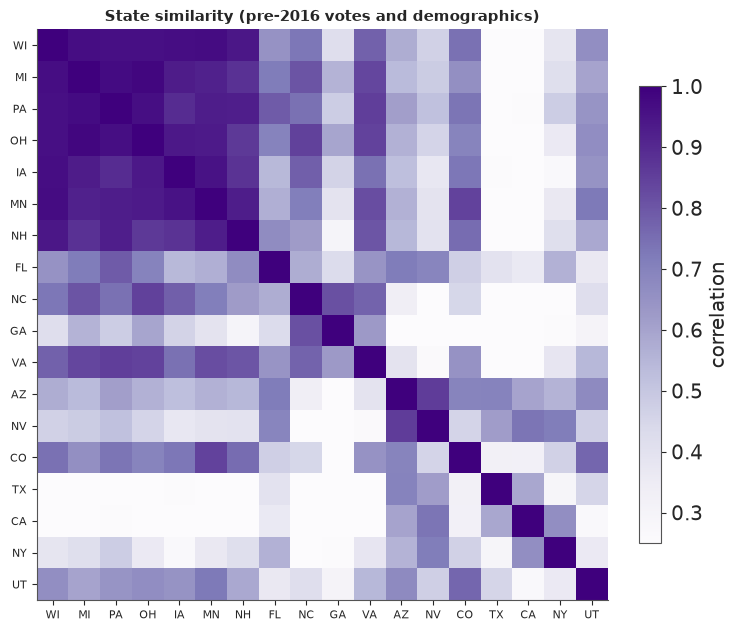

In [8]:
show = ["WI", "MI", "PA", "OH", "IA", "MN", "NH", "FL", "NC", "GA", "VA", "AZ", "NV", "CO", "TX", "CA", "NY", "UT"]
ix = [STATES.index(s) for s in show]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(C[np.ix_(ix, ix)], cmap="Purples", vmin=0.25, vmax=1)
ax.set_xticks(range(len(show)), show, fontsize=8)
ax.set_yticks(range(len(show)), show, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("State similarity (pre-2016 votes and demographics)", fontsize=11);

The Midwestern block (Wisconsin, Michigan, Pennsylvania, Ohio, Iowa, Minnesota) is strongly
correlated internally, the South-East (North Carolina, Georgia, Virginia) and the South-West
(Arizona, Nevada, Colorado) form looser groups, and Texas and California are barely tied to
the Midwest. Because of the 0.25 floor every state shares a national
component. Also printed: with a *national* standard deviation of 1, an individual state's sd
is about 1.4 - states move more than the nation, because their idiosyncratic parts average
out in the national total. All the error scales below are specified at the national level
and passed through this matrix.

> **In plain words:** states that look alike - similar people, similar voting history - tend
> to move together, and a polling mistake in one tends to show up in the others. The model is
> told which states are alike before it sees a single 2016 poll.

## 2 · The model

### 2.1 Structure

Everything lives on the logit scale of Clinton's two-party share. For state $s$ and week $t$
($t = T$ is the week ending on election day):

$$
\mu_{s,T} \sim \text{MVN}\big(\text{prior}_s,\ \sigma_T^2 \Sigma\big), \qquad
\mu_{\cdot,t} = \mu_{\cdot,t+1} + \sigma_{\text{walk}}\, \epsilon_t,\ \ \epsilon_t \sim \text{MVN}(0, \Sigma)
$$

(the **reverse random walk**: election day is anchored by the fundamentals, earlier weeks
wander away from it), with $\Sigma$ the unit-national-sd similarity covariance of 1.4. A poll
$i$ of state $s$ by pollster $p$ in mode $m$ and population $q$ in week $t$ measures

$$
\operatorname{logit}(\text{share}_i) \sim N\Big(\mu_{s,t} + \beta_s + h_p + m_m + q_q,\ \
\text{se}_i^2 + \tau^2\Big),
$$

where $\text{se}_i^2 = 1/(n_i\, \hat p_i (1-\hat p_i))$ is the pure **sampling** variance, $\tau$
the **excess poll-level noise** (question wording, weighting, timing - the things that make
two polls of the same week disagree by more than their margins of error), $h_p$ the
**house effect** of the pollster (zero-sum over pollsters: the *average* pollster is
unbiased), $m_m$ the **mode** effect (zero-sum), $q_q$ the **population** effect (likely
voters are the reference, since they are the ones who vote), and $\beta_s$ the
**systematic polling error** in state $s$: shared by *every* poll of that state, correlated
across states, $\beta \sim \text{MVN}(0, \sigma_\beta^2 \Sigma)$. A national poll measures
the turnout-weighted average $\sum_s w_s(\mu_{s,t} + \beta_s)$ plus its own house, mode and
population effects, with its own excess noise $\tau_{\text{nat}}$.

**Which scales are learned and which are set.** The polls themselves tell us how fast opinion
moves ($\sigma_{\text{walk}}$), how much pollsters differ ($\sigma_h$) and how much polls
disagree beyond sampling ($\tau$) - these get weakly informative priors. The **systematic
error $\beta$ is not identifiable from the polls**: if every poll in Wisconsin is 3 points too
kind to Clinton, the polls look exactly like a world in which Clinton is 3 points better off.
Its scale must come from the history of polling misses. We use the Economist's value, a
national sd of 1.3 points on the share scale, and look at what happens when it is removed or
doubled. The fundamentals sd $\sigma_T$ is the predictive sd from 1.3 (2.9 points).

### 2.2 A reparameterisation for the part the data cannot split

Only the sum $\mu_{\cdot,T} + \beta$ is measured by the polls. Non-centred, both are
$L z$ with $L$ the Cholesky factor of $\Sigma$: $\mu_{\cdot,T} = \text{prior} + \sigma_T L z_T$ and
$\beta = \sigma_\beta L z_\beta$. The data then constrain $\sigma_T z_T + \sigma_\beta z_\beta$
and leave the orthogonal direction to the prior: a long, thin ridge in $(z_T, z_\beta)$ that
NUTS explores slowly (a prototype had $\hat R$ up to 1.05 on the state paths). Rotating by
the angle of $(\sigma_T, \sigma_\beta)$,

$$
z_T = \frac{\sigma_T u + \sigma_\beta v}{r}, \qquad z_\beta = \frac{\sigma_\beta u - \sigma_T v}{r},
\qquad r = \sqrt{\sigma_T^2 + \sigma_\beta^2},
$$

gives $\sigma_T z_T + \sigma_\beta z_\beta = r\,u$: the polls see only $u$, and $v$ is exactly its
standard-normal prior. $u, v$ are still independent standard normals (a rotation), so the
model is unchanged - only easier to sample.

In [9]:
def build_model(poll_df, bias_scale=0.013, excess=True, walk_prior=0.05):
    """The forecasting model for the polls in poll_df (a subset of `polls`).

    bias_scale: national sd of the systematic polling error, on the share scale (0 = none).
    excess: include the poll-level excess noise tau.
    """
    st, na = poll_df[~poll_df.national], poll_df[poll_df.national]
    pollsters = sorted(poll_df.pollster.unique())
    s_idx = pd.Index(STATES).get_indexer(st.state)
    assert (s_idx >= 0).all()
    sd_T, sd_b = 4 * fund_sd, 4 * bias_scale          # share -> logit near 50%: x 4
    r = np.hypot(sd_T, sd_b)
    coords = {"state": STATES, "week": WEEK_END, "step": WEEK_END[:-1], "pollster": pollsters,
              "mode": MODES, "pop_other": POPS[1:]}
    with pm.Model(coords=coords) as model:
        u = pm.Normal("u", 0, 1, dims="state")
        v = pm.Normal("v", 0, 1, dims="state") if bias_scale > 0 else 0.0
        mu_T = prior_logit + sd_T * (L_UNIT @ ((sd_T * u + sd_b * v) / r))
        bias = pm.Deterministic("bias", sd_b * (L_UNIT @ ((sd_b * u - sd_T * v) / r)), dims="state")
        sd_walk = pm.HalfNormal("sd_walk", walk_prior)
        z_walk = pm.Normal("z_walk", 0, 1, dims=("step", "state"))
        steps = sd_walk * (z_walk @ L_UNIT.T)
        back = pt.cumsum(steps[::-1], axis=0)[::-1]           # sum of the steps from week t to T-1
        mu = pm.Deterministic("mu", pt.concatenate([mu_T[None, :] + back, mu_T[None, :]], axis=0),
                              dims=("week", "state"))
        sd_house = pm.HalfNormal("sd_house", 0.1)
        house = pm.Deterministic("house", sd_house * pm.ZeroSumNormal("z_house", 1, dims="pollster"),
                                 dims="pollster")
        mode_eff = pm.ZeroSumNormal("mode_eff", 0.05, dims="mode")
        pop_eff = pm.Normal("pop_eff", 0, 0.05, dims="pop_other")
        pop_all = pt.concatenate([pt.zeros(1), pop_eff])

        def adjust(df):
            return (house[pd.Index(pollsters).get_indexer(df.pollster)]
                    + mode_eff[pd.Index(MODES).get_indexer(df.mode3)]
                    + pop_all[pd.Index(POPS).get_indexer(df.population)])

        mean_state = mu[st.week.to_numpy(), s_idx] + bias[s_idx] + adjust(st)
        mean_nat = (mu[na.week.to_numpy()] + bias[None, :]) @ W + adjust(na)
        tau_state = pm.HalfNormal("tau_state", 0.05) if excess else 0.0
        tau_nat = pm.HalfNormal("tau_nat", 0.05) if excess else 0.0
        pm.Normal("y_state", mean_state, pt.sqrt(st.se.to_numpy() ** 2 + tau_state**2), observed=st.y.to_numpy())
        pm.Normal("y_nat", mean_nat, pt.sqrt(na.se.to_numpy() ** 2 + tau_nat**2), observed=na.y.to_numpy())
    return model


eve = polls[polls.end <= "2016-11-07"]
main_model = build_model(eve)
print(f"election-eve model: {len(eve):,} polls, "
      f"{sum(v.size for v in main_model.initial_point().values()):,} unconstrained parameters")

election-eve model: 1,620 polls, 2,144 unconstrained parameters


### 2.3 Prior predictive check: the forecast before any poll

With the likelihood switched off, the model is just the fundamentals, the similarity matrix
and the random walk. What does it believe about the national vote over the campaign and about
the electoral college?

prior: national share on election day 0.503 (90% 0.458-0.551); in March 0.393-0.619
prior P(Clinton >= 270 EV) = 0.56; EV 90% 168-368


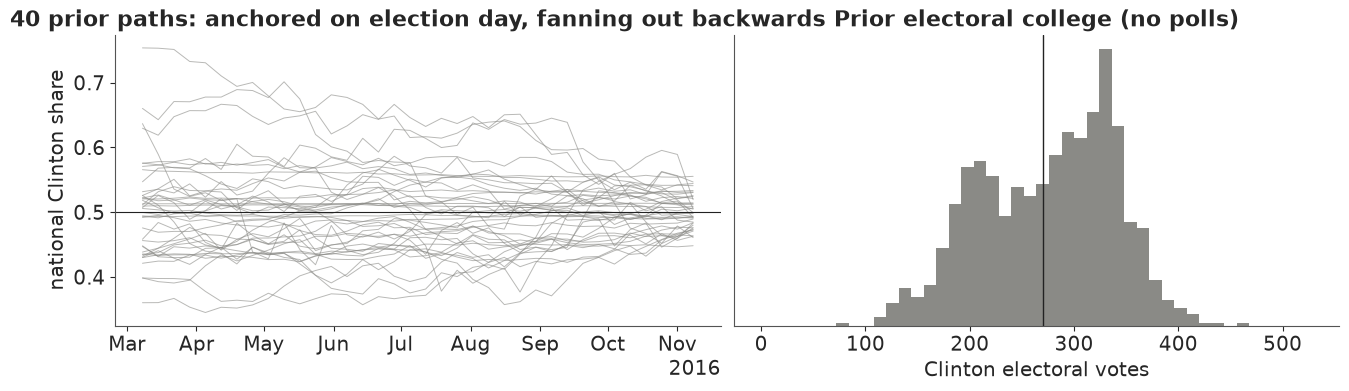

In [10]:
with main_model:
    prior = pm.sample_prior_predictive(draws=1000, var_names=["mu", "sd_walk"], random_seed=RANDOM_SEED)
prior_mu = stacked(prior.prior["mu"])                          # (draw, week, state)
prior_nat = expit(prior_mu) @ W                                # national share by week
prior_final = expit(prior_mu[:, -1])
prior_ev = (prior_final > 0.5) @ EV
print(f"prior: national share on election day {np.median(prior_nat[:, -1]):.3f} "
      f"(90% {np.quantile(prior_nat[:, -1], 0.05):.3f}-{np.quantile(prior_nat[:, -1], 0.95):.3f}); "
      f"in March {np.quantile(prior_nat[:, 0], 0.05):.3f}-{np.quantile(prior_nat[:, 0], 0.95):.3f}")
print(f"prior P(Clinton >= 270 EV) = {np.mean(prior_ev >= 270):.2f}; EV 90% {np.quantile(prior_ev, 0.05):.0f}-"
      f"{np.quantile(prior_ev, 0.95):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for k in rng.choice(len(prior_nat), 40, replace=False):
    axes[0].plot(WEEK_END, prior_nat[k], color=GREY, lw=0.7, alpha=0.6)
axes[0].axhline(0.5, color=TRUTH, lw=0.8)
axes[0].set(ylabel="national Clinton share", title="40 prior paths: anchored on election day, fanning out backwards")
date_axis(axes[0])
axes[1].hist(prior_ev, bins=np.arange(0, 539, 12), color=GREY)
axes[1].axvline(270, color=TRUTH, lw=1)
axes[1].set(xlabel="Clinton electoral votes", title="Prior electoral college (no polls)", yticks=[]);
del prior, prior_mu

Before any poll the model says "anything from a clear Trump win to a clear Clinton win": a
56% chance for Clinton and a 90% electoral-vote range of about 170 to 370. The paths fan out
*backwards* from election day - the fundamentals hold the end point to within a few points
(90%: 45.8% to 55.1%), while by March the walk has wandered to anywhere between about 39% and
62%. The electoral-college histogram is lumpy and two-humped, because similar states flip
together. The walk's prior scale (HalfNormal(0.05) per week, national, logit) allows
months-long swings of several points; the polls will pin it down.

## 3 · The election-eve forecast

### 3.1 Fit and diagnostics

All polls that finished fielding by 7 November 2016, the day before the election. To keep
memory small we store only the state paths and the scalar parameters. We use
`target_accept=0.95` for every fit in this notebook: with few polls (the June forecast below)
the default 0.8 gave about 60 divergences, all at small excess-noise and large random-walk
scales, and 0.95 removed them at no extra cost in time.

In [11]:
KEEP = ["mu", "bias", "house", "sd_walk", "sd_house", "mode_eff", "pop_eff", "tau_state", "tau_nat"]
with main_model:
    idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False, var_names=KEEP)
summ = az.summary(idata, var_names=["sd_walk", "sd_house", "tau_state", "tau_nat", "mode_eff", "pop_eff"],
                  round_to=3)
rh = az.rhat(idata)
ess = az.ess(idata)
print(f"sampler nutpie, tuning steps {idata.posterior.attrs.get('tuning_steps')}, divergences "
      f"{int(idata.sample_stats['diverging'].sum())}, mean tree depth {float(idata.sample_stats['depth'].mean()):.1f}")
print(f"state paths mu: max r_hat {float(rh['mu'].max()):.3f}, min bulk ESS {float(ess['mu'].min()):.0f}; "
      f"house effects: max r_hat {float(rh['house'].max()):.3f}")
summ

sampler nutpie, tuning steps 400, divergences 0, mean tree depth 6.9
state paths mu: max r_hat 1.006, min bulk ESS 1985; house effects: max r_hat 1.008


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sd_walk,0.026,0.003,0.022,0.031,1230.388,1821.235,1.005,0.0,0.000
sd_house,0.051,0.006,0.042,0.061,1203.476,1622.873,1.008,0.0,0.000
tau_state,0.040,0.004,0.033,0.047,2700.736,2542.370,1.001,0.0,0.000
tau_nat,0.026,0.004,0.020,0.032,5690.568,3227.261,1.001,0.0,0.000
mode_eff[live phone],0.010,0.007,-0.000,0.021,2075.112,2349.488,1.001,0.0,0.000
mode_eff[online],0.010,0.009,-0.004,0.024,1063.362,1360.922,1.005,0.0,0.000
mode_eff[other],-0.020,0.008,-0.033,-0.007,1771.204,2413.540,1.002,0.0,0.000
pop_eff[Registered Voters],0.002,0.008,-0.011,0.016,3722.951,2921.911,1.000,0.0,0.000
pop_eff[Adults],-0.030,0.039,-0.093,0.032,8944.004,3420.945,1.002,0.0,0.001


No divergences, $\hat R$ at most about 1.01, and bulk ESS near 2,000 or more for all 1,836
state-week values and above 1,000 for every scale parameter. What the scales mean, converting
logit to share by dividing by 4:

- **`sd_walk`** about 0.026: national opinion moves by about 0.65 points of two-party share per
  week (one sd), so about 4 points over the 35 weeks - the walk is fairly calm, as Linzer found.
- **`sd_house`** about 0.05: a typical pollster leans by about 1.3 points one way or the other.
- **`tau_state`** about 0.04 and **`tau_nat`** about 0.026: polls disagree beyond their sampling
  error by about 1 point (state) and 0.6 points (national) of share. For a typical state poll
  of 600 people the sampling sd is 0.08 on the logit scale, so the excess noise adds about a
  quarter to its variance; for the big online national panels it dominates.
- **Mode and population effects** are small: "other" modes (IVR/robo-polls and mixes) about
  half a point less favourable to Clinton than the average, and registered-voter polls not
  clearly different from likely-voter polls.

### 3.2 Does the model reproduce the polls?

Posterior predictive check in poll space: for each poll, simulate a replicate from the fitted
model (latent opinion + adjustments + noise) and ask where the observed poll falls. If the
noise model is right, the PIT values are uniform and about 90% of polls fall in their 90%
predictive intervals.

national polls: 93% inside their 90% predictive interval, 63% inside the 50% interval
state polls: 95% inside their 90% predictive interval, 63% inside the 50% interval


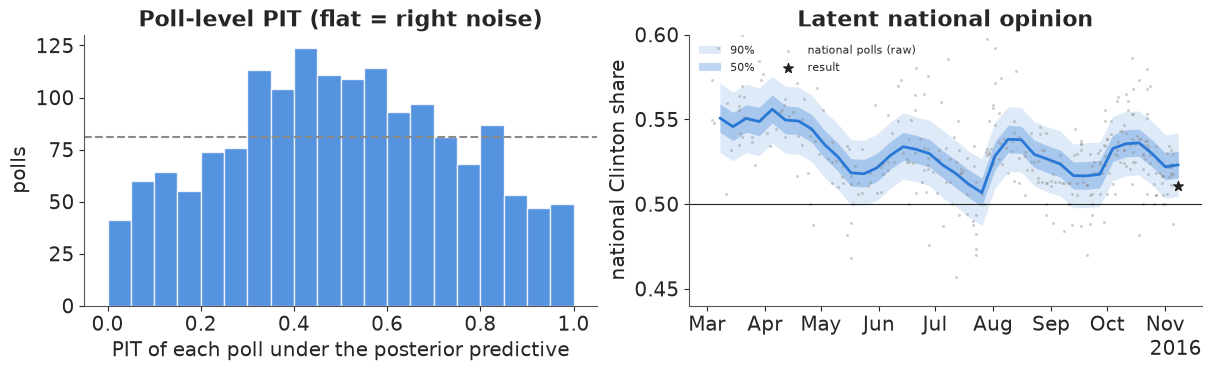

In [12]:
post = {k: stacked(idata.posterior[k]) for k in ["mu", "bias", "house", "mode_eff", "pop_eff", "tau_state", "tau_nat"]}
thin = np.arange(0, len(post["mu"]), 4)                        # 1000 draws are plenty here
pollsters_eve = list(idata.posterior.coords["pollster"].to_numpy())


def poll_mean(p, df):
    """Posterior draws (draw, poll) of the expected logit share of each poll in df."""
    pop_all = np.column_stack([np.zeros(len(p["pop_eff"])), p["pop_eff"]])
    adj = (p["house"][:, pd.Index(pollsters_eve).get_indexer(df.pollster)]
           + p["mode_eff"][:, pd.Index(MODES).get_indexer(df.mode3)]
           + pop_all[:, pd.Index(POPS).get_indexer(df.population)])
    wk = df.week.to_numpy()
    si = np.clip(pd.Index(STATES).get_indexer(df.state), 0, None)      # national rows: any index, masked below
    nat_lat = (p["mu"] + p["bias"][:, None, :]) @ W                     # (draw, week)
    lat = np.where(df.national.to_numpy()[None, :], nat_lat[:, wk], p["mu"][:, wk, si] + p["bias"][:, si])
    return lat + adj


pt_draws = {k: v[thin] for k, v in post.items()}
m_eve = poll_mean(pt_draws, eve)
sd_eve = np.sqrt(eve.se.to_numpy()[None, :] ** 2
                 + np.where(eve.national.to_numpy()[None, :], pt_draws["tau_nat"][:, None], pt_draws["tau_state"][:, None]) ** 2)
y_rep = m_eve + sd_eve * rng.standard_normal(m_eve.shape)
pit_polls = (y_rep < eve.y.to_numpy()[None, :]).mean(0)
for label, mask in [("national", eve.national.to_numpy()), ("state", ~eve.national.to_numpy())]:
    print(f"{label} polls: {np.mean(np.abs(pit_polls[mask] - 0.5) <= 0.45):.0%} inside their 90% predictive "
          f"interval, {np.mean(np.abs(pit_polls[mask] - 0.5) <= 0.25):.0%} inside the 50% interval")
del y_rep, m_eve, sd_eve

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(pit_polls, bins=np.linspace(0, 1, 21), color=DEM, alpha=0.8, edgecolor="white")
axes[0].axhline(len(pit_polls) / 20, color=GREY, ls="--")
axes[0].set(xlabel="PIT of each poll under the posterior predictive", ylabel="polls",
            title="Poll-level PIT (flat = right noise)")
nat_path = expit(post["mu"]) @ W                              # (draw, week) national share
q = np.quantile(nat_path, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
axes[1].fill_between(WEEK_END, q[0], q[4], color=DEM, alpha=0.15, lw=0, label="90%")
axes[1].fill_between(WEEK_END, q[1], q[3], color=DEM, alpha=0.3, lw=0, label="50%")
axes[1].plot(WEEK_END, q[2], color=DEM, lw=2)
axes[1].scatter(nat.mid, nat.share, s=5, color=GREY, alpha=0.4, lw=0, label="national polls (raw)")
axes[1].scatter([ELECTION], [np.dot(actual, W)], color=TRUTH, s=50, marker="*", zorder=5, label="result")
axes[1].axhline(0.5, color=TRUTH, lw=0.8)
axes[1].set(ylim=(0.44, 0.6), ylabel="national Clinton share", title="Latent national opinion")
axes[1].legend(fontsize=8, loc="upper left", ncol=2)
date_axis(axes[1]);

No poll is grossly out of line, but the PIT histogram is hump-shaped: about 63% of polls fall
inside their 50% predictive intervals instead of 50%, and too few land in the extreme tails.
The predictive distribution is too *wide* for the typical poll, which is what a normal noise
model does when the real errors are heavier-tailed: a few outlying polls inflate $\tau$ and
every other poll then looks unusually well-behaved. A Student-t poll likelihood would fit
better (try it); it would hardly change the forecast, which rests on the average of many
polls. The latent national opinion (right) runs *through* the polls - by construction, since
the average pollster is assumed unbiased - and on election day the result (star) is near the
bottom of its 90% band. The PPC cannot detect that: a polling error shared by all polls is
invisible in poll space. **Checking a forecast model against its own polls says nothing about
the systematic error; only the election does.**

### 3.3 The swing states, week by week

result vs the election-day 90% band: {'FL': 'inside', 'PA': 'inside', 'MI': 'below', 'WI': 'below', 'NC': 'inside', 'OH': 'below'}


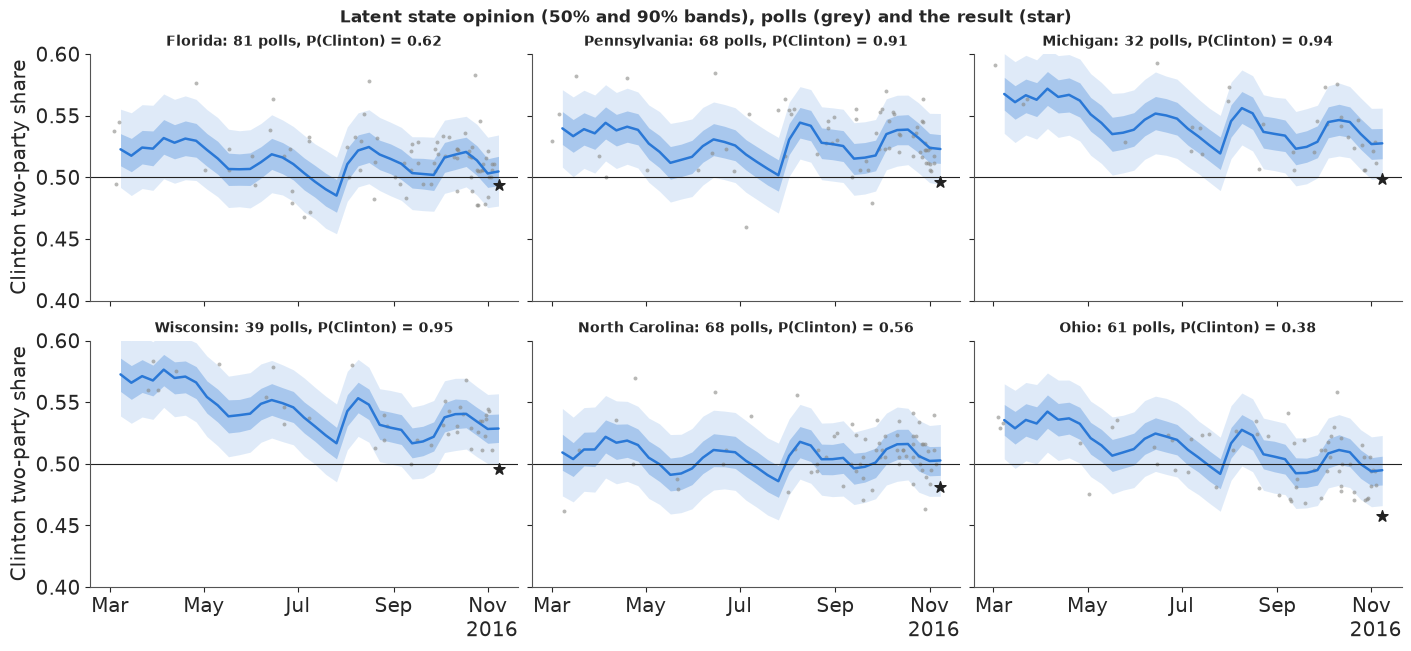

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4), sharex=True, sharey=True)
for ax, s in zip(axes.flat, SWING):
    i = STATES.index(s)
    path = expit(post["mu"][:, :, i])
    q = np.quantile(path, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
    ax.fill_between(WEEK_END, q[0], q[4], color=DEM, alpha=0.15, lw=0)
    ax.fill_between(WEEK_END, q[1], q[3], color=DEM, alpha=0.3, lw=0)
    ax.plot(WEEK_END, q[2], color=DEM, lw=1.8)
    d = eve[eve.state == s]
    ax.scatter(d.mid, d.share, s=8, color=GREY, alpha=0.6, lw=0)
    ax.scatter([ELECTION], [actual[i]], color=TRUTH, marker="*", s=70, zorder=5)
    ax.axhline(0.5, color=TRUTH, lw=0.8)
    p_win = np.mean(path[:, -1] > 0.5)
    ax.set_title(f"{STATE_NAMES[s]}: {len(d)} polls, P(Clinton) = {p_win:.2f}", fontsize=10)
    ax.set_ylim(0.4, 0.6)
    date_axis(ax)
axes[0, 0].set_ylabel("Clinton two-party share")
axes[1, 0].set_ylabel("Clinton two-party share")
fig.suptitle("Latent state opinion (50% and 90% bands), polls (grey) and the result (star)", fontsize=12)
lo_sw, hi_sw = np.quantile(expit(post["mu"][:, -1, [STATES.index(s) for s in SWING]]), [0.05, 0.95], axis=0)
print("result vs the election-day 90% band:", {s: "below" if a < lo else ("inside" if a <= hi else "above")
                                                for s, a, lo, hi in zip(SWING, actual[[STATES.index(s) for s in SWING]], lo_sw, hi_sw)})

In all six states the result sits below the model's median: in Michigan, Wisconsin and Ohio
below the 90% band, in Pennsylvania just inside its lower edge. Florida and North Carolina
were close calls that went to Trump; Ohio was leaning to him already. Michigan and Wisconsin had
only
32 and 39 polls, and their paths follow the national dips and bounces (the August convention
bounce is visible everywhere): weeks without a poll borrow from the other states through the
correlated walk.

### 3.4 House effects

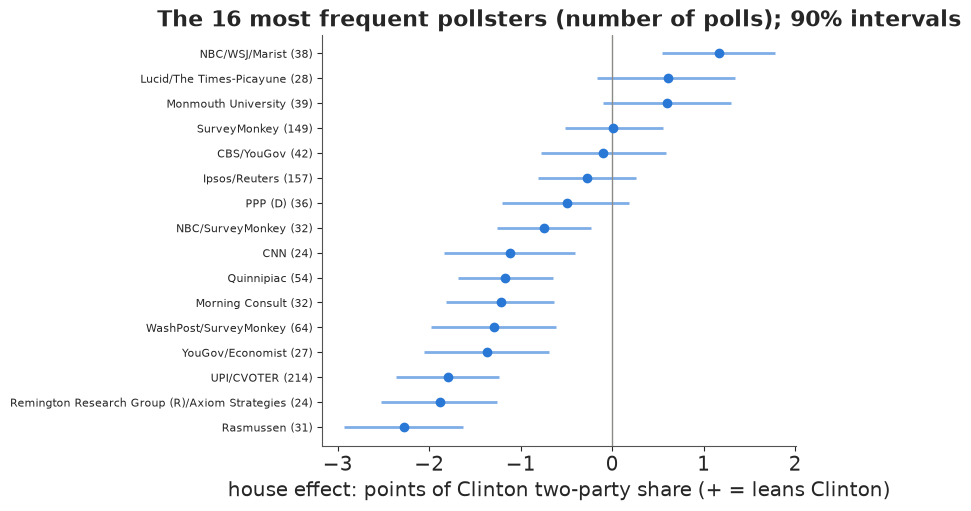

In [14]:
house = pd.DataFrame(post["house"], columns=pollsters_eve) / 4 * 100     # points of two-party share
n_by = eve.pollster.value_counts()
top = n_by.index[:16]
hq = house[top].quantile([0.05, 0.5, 0.95]).T.sort_values(0.5)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(range(len(hq)), hq[0.05], hq[0.95], color=DEM, lw=2, alpha=0.6)
ax.scatter(hq[0.5], range(len(hq)), color=DEM, zorder=3)
ax.axvline(0, color=GREY, lw=1)
ax.set_yticks(range(len(hq)), [f"{p} ({n_by[p]})" for p in hq.index], fontsize=8)
ax.set(xlabel="house effect: points of Clinton two-party share (+ = leans Clinton)",
       title="The 16 most frequent pollsters (number of polls); 90% intervals");

House effects are relative to the *average* pollster, not to the truth. Among the frequent
pollsters, NBC/WSJ/Marist leaned towards Clinton by about a point, and Rasmussen, Remington
and the UPI/CVOTER tracker towards Trump by about two; most intervals are a point or two
wide. Correcting for house effects makes the polls *consistent* with each other; it cannot
make their average *right* - and in 2016 the Trump-leaning houses were closer to the result.

> **In plain words:** the model follows opinion in every state week by week, knows which
> polling companies tend to lean which way, and reproduces the polls well. None of that could
> reveal that the polls as a whole were too kind to Clinton - the model can only allow for
> that possibility, based on how often polls have been wrong before.

## 4 · From state opinion to the electoral college

Each posterior draw is a complete, internally consistent election: a two-party share in all 51
states. Counting the electoral votes of the states Clinton carries in each draw gives the
distribution of the electoral college; the share of draws with 270 or more is her win
probability. The **tipping-point state** of a draw is the state that delivers the winner's
270th electoral vote when states are sorted from the winner's best to worst (Silver's
definition): the state where the election is decided.

In [15]:
def ec_summary(final_share):
    """Electoral college from (draw, state) election-day shares."""
    ev_c = (final_share > 0.5) @ EV
    clinton_wins = ev_c >= 270
    order = np.argsort(-final_share, axis=1)                     # Clinton's best state first
    cum_c = np.cumsum(EV[order], axis=1)
    tip_c = order[np.arange(len(order)), np.argmax(cum_c >= 270, axis=1)]
    order_t = order[:, ::-1]                                     # Trump's best state first
    cum_t = np.cumsum(EV[order_t], axis=1)
    tip_t = order_t[np.arange(len(order)), np.argmax(cum_t >= 269, axis=1)]
    tip = np.where(clinton_wins, tip_c, tip_t)
    return ev_c, clinton_wins, tip


final = expit(post["mu"][:, -1])                                  # (4000, 51) election-day shares
ev_c, c_wins, tip = ec_summary(final)
p_state = (final > 0.5).mean(0)
tip_p = pd.Series(np.bincount(tip, minlength=S) / len(tip), index=STATES).sort_values(ascending=False)
nat_final = final @ W
_, _, actual_tip = ec_summary(actual[None, :])
print(f"P(Clinton wins) = {c_wins.mean():.2f}; Clinton EV median {np.median(ev_c):.0f} "
      f"(90% {np.quantile(ev_c, 0.05):.0f}-{np.quantile(ev_c, 0.95):.0f}); actual {actual_ev}")
print(f"national two-party share {np.median(nat_final):.3f} (90% {np.quantile(nat_final, 0.05):.3f}-"
      f"{np.quantile(nat_final, 0.95):.3f}); actual {np.dot(actual, W):.3f}")
print(f"P(Clinton wins the popular vote but loses the electoral college) = {np.mean((nat_final > 0.5) & ~c_wins):.3f}")
print("tipping-point probabilities:", tip_p.head(8).round(2).to_dict())
print(f"actual 2016 tipping-point state: {STATES[actual_tip[0]]} (model probability {tip_p[STATES[actual_tip[0]]]:.2f})")
print("P(Clinton carries):", pd.Series(p_state, index=STATES)[["FL", "NC", "PA", "MI", "WI", "OH", "IA", "NH", "NV"]].round(2).to_dict())

P(Clinton wins) = 0.88; Clinton EV median 312 (90% 243-363); actual 233
national two-party share 0.523 (90% 0.504-0.542); actual 0.511
P(Clinton wins the popular vote but loses the electoral college) = 0.097
tipping-point probabilities: {'PA': 0.24, 'FL': 0.13, 'MI': 0.11, 'NC': 0.08, 'NH': 0.08, 'CO': 0.08, 'VA': 0.07, 'NV': 0.06}
actual 2016 tipping-point state: WI (model probability 0.06)
P(Clinton carries): {'FL': 0.62, 'NC': 0.56, 'PA': 0.91, 'MI': 0.94, 'WI': 0.95, 'OH': 0.38, 'IA': 0.28, 'NH': 0.91, 'NV': 0.77}


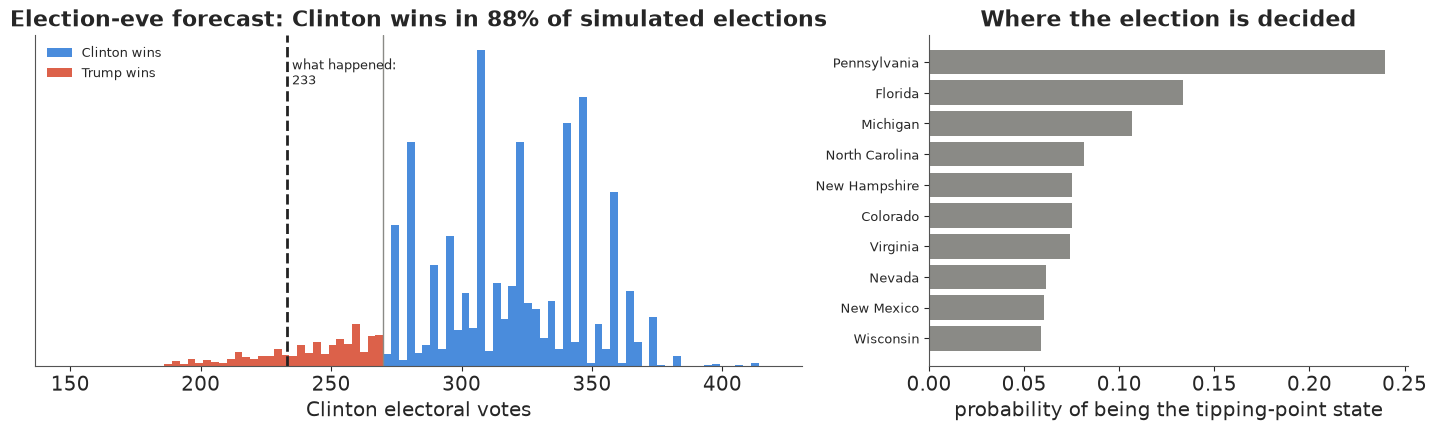

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
bins = np.arange(150, 420, 3)
axes[0].hist(ev_c[c_wins], bins=bins, color=DEM, alpha=0.85, label="Clinton wins")
axes[0].hist(ev_c[~c_wins], bins=bins, color=REP, alpha=0.85, label="Trump wins")
axes[0].axvline(270, color=GREY, lw=1)
axes[0].axvline(actual_ev, color=TRUTH, lw=2, ls="--")
axes[0].text(actual_ev + 2, axes[0].get_ylim()[1] * 0.85, f"what happened:\n{actual_ev}", fontsize=9)
axes[0].set(xlabel="Clinton electoral votes", yticks=[],
            title=f"Election-eve forecast: Clinton wins in {100 * c_wins.mean():.0f}% of simulated elections")
axes[0].legend(fontsize=9, loc="upper left")
tp = tip_p.head(10)[::-1]
axes[1].barh(range(len(tp)), tp.to_numpy(), color=GREY)
axes[1].set_yticks(range(len(tp)), [STATE_NAMES[s] for s in tp.index], fontsize=9)
axes[1].set(xlabel="probability of being the tipping-point state", title="Where the election is decided");

On election eve the model gives Clinton close to a 9-in-10 chance, with a median around 310
electoral votes and a 90% range of about 243 to 363. The distribution is lumpy (Florida's 29
and Pennsylvania's 20 electoral votes move in blocks) and has a long left tail of correlated
losses; the real result, 233, lies beyond its 5th percentile. Pennsylvania is the likeliest
tipping point by far, then Florida and Michigan; the actual tipping-point state, Wisconsin,
gets only about 6% - the model had it as safer for Clinton than Pennsylvania or Michigan.
And the split that actually happened - Clinton wins the popular vote but loses the electoral
college - has a probability of about 1 in 10: it makes up most of the simulated Trump wins. The
model knew *how* Clinton could lose; it thought it unlikely.

> **In plain words:** on the eve of the election this model said Clinton would win about 9 times
> in 10. Trump's path ran through Pennsylvania, Michigan and Wisconsin together - and that is
> the path the real election took.

## 5 · Honest evaluation against what happened

### 5.1 State by state

state results inside the 50% interval: 31%, inside the 90% interval: 55%
states called wrong (P > 0.5 for the loser): ['FL', 'MI', 'NC', 'PA', 'WI']
median error (forecast median - result): +2.4 points; 76% of states overstated Clinton
largest misses (points): {'ND': 9.3, 'WV': 7.8, 'SD': 6.5, 'WY': 5.4, 'TN': 4.9, 'MO': 4.7}


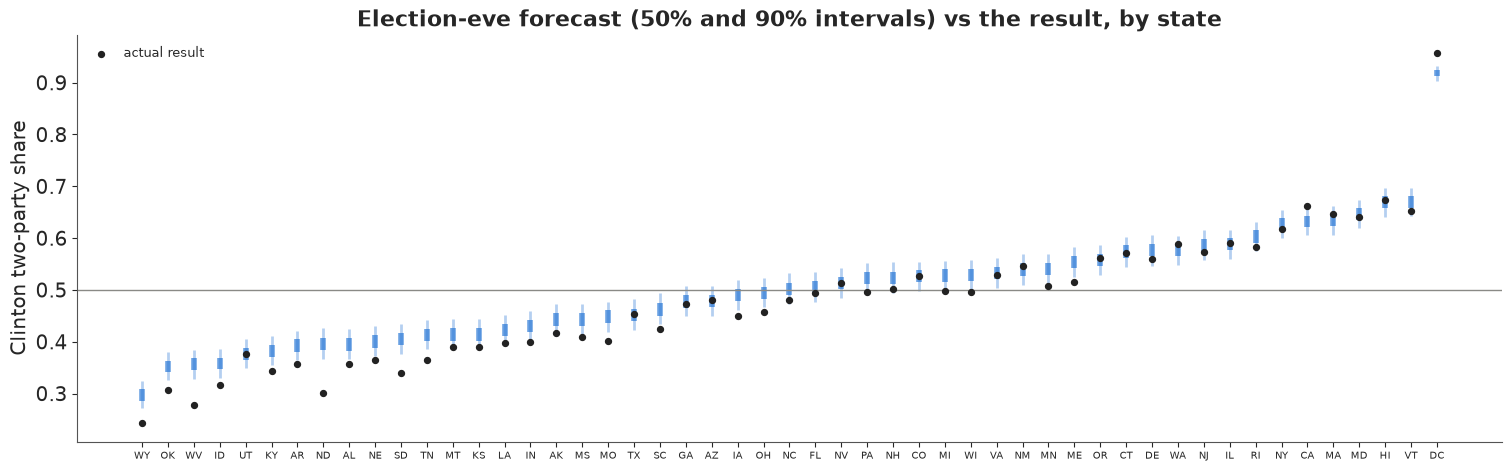

In [17]:
q05, q25, q50, q75, q95 = np.quantile(final, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
pit_states = (final < actual).mean(0)
cover50 = np.mean((actual >= q25) & (actual <= q75))
cover90 = np.mean((actual >= q05) & (actual <= q95))
wrong_call = [s for s, p, a in zip(STATES, p_state, actual) if (p > 0.5) != (a > 0.5)]
print(f"state results inside the 50% interval: {cover50:.0%}, inside the 90% interval: {cover90:.0%}")
print(f"states called wrong (P > 0.5 for the loser): {wrong_call}")
print(f"median error (forecast median - result): {100 * np.median(q50 - actual):+.1f} points; "
      f"{np.mean(q50 > actual):.0%} of states overstated Clinton")
print("largest misses (points):", (100 * pd.Series(q50 - actual, index=STATES)).sort_values().tail(6).round(1)[::-1].to_dict())

order = np.argsort(q50)
fig, ax = plt.subplots(figsize=(15, 4.6))
x = np.arange(S)
ax.vlines(x, q05[order], q95[order], color=DEM, lw=2, alpha=0.35)
ax.vlines(x, q25[order], q75[order], color=DEM, lw=4, alpha=0.7)
ax.scatter(x, actual[order], color=TRUTH, s=18, zorder=4, label="actual result")
ax.axhline(0.5, color=GREY, lw=1)
ax.set_xticks(x, [STATES[i] for i in order], fontsize=7)
ax.set(ylabel="Clinton two-party share", title="Election-eve forecast (50% and 90% intervals) vs the result, by state")
ax.legend(loc="upper left", fontsize=9);

The intervals are too narrow for 2016: only about 55% of the states fall inside their 90%
intervals and about 30% inside their 50% intervals, and the misses are nearly all on the same
side -
the forecast median is above the result in three states out of four, by 2.4 points in the
median state. The biggest misses are in rural, white, heavily Republican states that were
barely polled (North Dakota, West Virginia, South Dakota, Wyoming, Tennessee), and the decisive
ones in the Midwest: five states were called wrong (Florida, Michigan, North Carolina,
Pennsylvania, Wisconsin), all for Clinton. That is what a **correlated** error looks like:
51 states do not give 51 independent chances to be right, they give a handful. The joint
check below takes that into account.

### 5.2 A joint calibration check

Treat the 51 election-day shares as one vector. Under the model the squared Mahalanobis
distance of a simulated election from the forecast mean has some distribution (a
$\chi^2_{51}$ if everything were Gaussian); where does the real 2016 fall in it? A value
beyond the 95th percentile means the real map is an outlier *even allowing for the correlation*.

In [18]:
def joint_distance(draws, truth):
    """Squared Mahalanobis distance (logit scale) of the truth, and the 99th percentile of the draws' own."""
    z = logit(draws)
    m, cov = z.mean(0), np.cov(z, rowvar=False)
    prec = np.linalg.inv(cov)
    d_draws = np.einsum("ij,jk,ik->i", z - m, prec, z - m)
    d_true = (logit(truth) - m) @ prec @ (logit(truth) - m)
    return d_true, np.quantile(d_draws, 0.99)


d2, d2_99 = joint_distance(final, actual)
print(f"actual 2016 map: squared distance {d2:.0f}; simulated elections: 99th percentile {d2_99:.0f} "
      f"(chi-square(51) 99th percentile {stats.chi2.ppf(0.99, S):.0f})")

actual 2016 map: squared distance 227; simulated elections: 99th percentile 77 (chi-square(51) 99th percentile 77)


The actual map is far outside the cloud of simulated elections: its distance is several times
the 99th percentile of the model's own draws. So the model's *joint* picture of how states can
miss together was too tight, not only its individual intervals: the real error had a
*pattern* (rural and white working-class states far more than the rest) that a similarity
matrix with a 0.25 floor and a single error scale did not anticipate. We come back to this
number for the other error models.

### 5.3 What the forecast said at the time

A forecast should be judged by what it said *then*, using only the polls available then.
We refit the same model with the polls that had finished fielding by six dates - mid-June,
the start of August (after both conventions), 1 September, 1 October (after the first
debate), 20 October (after the *Access Hollywood* tape and the third debate) and election eve -
and record the win probability and the forecast for each state.

In [19]:
AS_OF = [pd.Timestamp(d) for d in ["2016-06-15", "2016-08-01", "2016-09-01", "2016-10-01", "2016-10-20", "2016-11-07"]]
timeline = []
for as_of in AS_OF:
    if as_of == AS_OF[-1]:
        fin = final
    else:
        with build_model(polls[polls.end <= as_of]):
            fit = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False, var_names=["mu"])
        mu_d = stacked(fit.posterior["mu"])
        ok = (int(fit.sample_stats["diverging"].sum()), float(az.rhat(fit)["mu"].max()))
        fin = expit(mu_d[:, -1])
        del fit, mu_d
    ev_d, win_d, _ = ec_summary(fin)
    lo, hi = np.quantile(fin, [0.05, 0.95], axis=0)
    timeline.append({"as_of": as_of, "n_polls": int((polls.end <= as_of).sum()), "p_clinton": win_d.mean(),
                     "ev_q": np.quantile(ev_d, [0.05, 0.25, 0.5, 0.75, 0.95]), "nat": np.quantile(fin @ W, [0.05, 0.5, 0.95]),
                     "cover90": np.mean((actual >= lo) & (actual <= hi)), "ev_draws": ev_d[::20],
                     "state_q": np.quantile(fin, [0.05, 0.5, 0.95], axis=0), "p_state": (fin > 0.5).mean(0),
                     "diag": ok if as_of != AS_OF[-1] else (int(idata.sample_stats["diverging"].sum()), float(rh["mu"].max()))})
tl = pd.DataFrame([{"as of": t["as_of"].date(), "polls": t["n_polls"], "P(Clinton)": round(t["p_clinton"], 2),
                    "EV median": int(t["ev_q"][2]), "EV 90%": f"{t['ev_q'][0]:.0f}-{t['ev_q'][4]:.0f}",
                    "national 90%": f"{t['nat'][0]:.3f}-{t['nat'][2]:.3f}", "90% cover": round(t["cover90"], 2),
                    "divergences": t["diag"][0], "max r_hat": round(t["diag"][1], 3)} for t in timeline])
tl

,as of,polls,P(Clinton),EV median,EV 90%,national 90%,90% cover,divergences,max r_hat
0,2016-06-15,202,0.69,303,191-379,0.475-0.554,0.86,0,1.014
1,2016-08-01,371,0.71,304,196-374,0.478-0.550,0.84,0,1.012
2,2016-09-01,554,0.76,318,203-378,0.486-0.552,0.82,0,1.006
3,2016-10-01,770,0.82,318,216-372,0.493-0.550,0.76,0,1.007
4,2016-10-20,1098,0.91,329,252-368,0.504-0.552,0.57,0,1.005
5,2016-11-07,1620,0.88,312,243-363,0.504-0.542,0.55,0,1.006


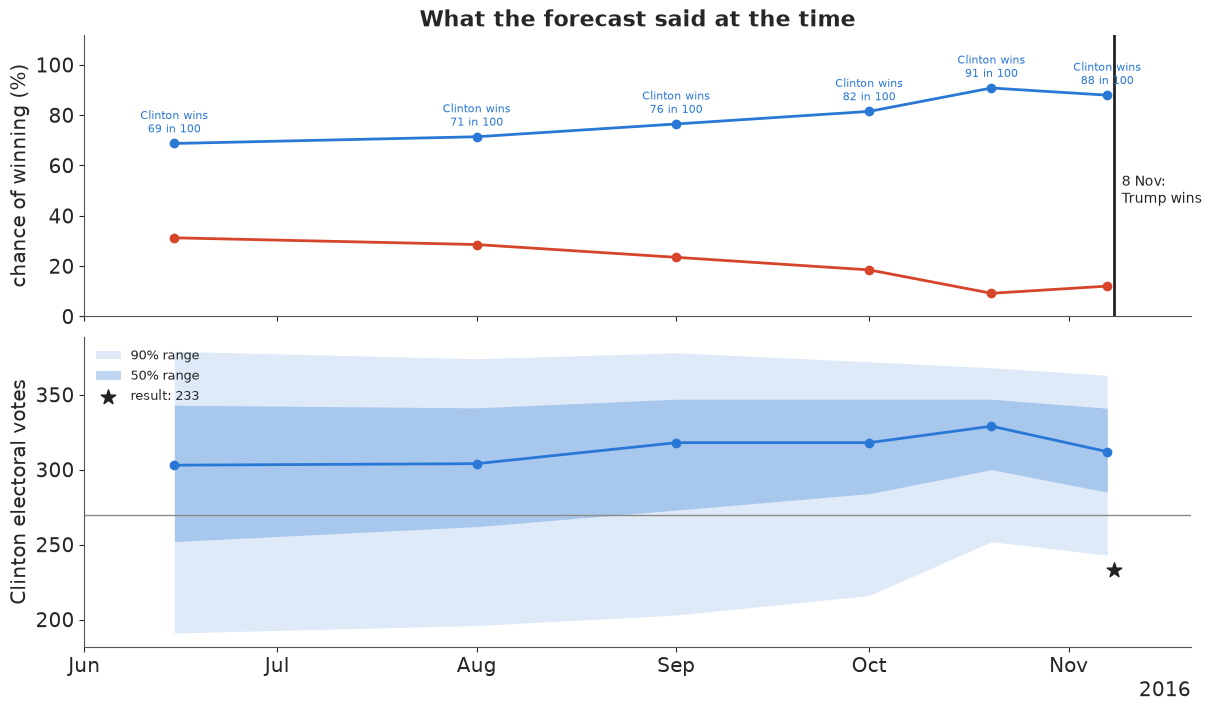

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.1]})
dates = [t["as_of"] for t in timeline]
pc = np.array([t["p_clinton"] for t in timeline])
axes[0].plot(dates, 100 * pc, color=DEM, marker="o", lw=2)
axes[0].plot(dates, 100 * (1 - pc), color=REP, marker="o", lw=2)
for d, p in zip(dates, pc):
    axes[0].annotate(f"Clinton wins\n{100 * p:.0f} in 100", (d, 100 * p), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8, color=DEM)
axes[0].axvline(ELECTION, color=TRUTH, lw=2)
axes[0].text(ELECTION, 50, "  8 Nov:\n  Trump wins", fontsize=10, va="center")
axes[0].set(ylim=(0, 112), ylabel="chance of winning (%)", title="What the forecast said at the time")
evq = np.array([t["ev_q"] for t in timeline])
axes[1].fill_between(dates, evq[:, 0], evq[:, 4], color=DEM, alpha=0.15, lw=0, label="90% range")
axes[1].fill_between(dates, evq[:, 1], evq[:, 3], color=DEM, alpha=0.3, lw=0, label="50% range")
axes[1].plot(dates, evq[:, 2], color=DEM, marker="o", lw=2)
axes[1].axhline(270, color=GREY, lw=1)
axes[1].scatter([ELECTION], [actual_ev], color=TRUTH, marker="*", s=120, zorder=5, label=f"result: {actual_ev}")
axes[1].set(ylabel="Clinton electoral votes", xlim=(pd.Timestamp("2016-06-01"), ELECTION + pd.Timedelta(days=12)))
axes[1].legend(loc="upper left", fontsize=9)
date_axis(axes[1]);

The forecast moved with the campaign: about seven in ten for Clinton in June and August,
three in four on 1 September, four in five on 1 October, and about 9 in 10 after the third
debate and on election eve.
From 20 October on, the electoral-college 90% range no longer reached down to the actual
result. The earlier forecasts were less confident *and* better calibrated: their state
intervals, wider because the election was further away, contained 76-86% of the actual results
(the "90% cover" column), against 55-57% at the end. A forecast that gets more confident as
the polls pile up is behaving as designed; the problem was that the polls piled up in the
wrong place.

> **In plain words:** all summer the model gave Clinton about a seven-in-ten chance; by the
> eve of the election, about nine in ten. It never said she was certain - and the model's own
> range of outcomes was still too narrow for what happened.

### 5.4 The failure: a forecast with sampling error only

Most of the "99% Clinton" forecasts of 2016 were, in effect, poll averages whose uncertainty was
the sampling error of the average. Here is that model, and the ladder back to ours: (a)
**sampling error only** (no excess noise, no systematic error), (b) + **poll-level excess
noise** $\tau$, (c) + **systematic error** at the Economist's scale (our main model), and (d)
**systematic error doubled** (2.6 points national sd), the kind of widening forecasters
adopted after 2016. All on the election-eve polls.

In [21]:
ladder = {}
for label, kw in [("sampling error only", {"bias_scale": 0.0, "excess": False}),
                  ("+ poll-level noise", {"bias_scale": 0.0}),
                  ("+ systematic error (main)", None),
                  ("systematic error x2", {"bias_scale": 0.026})]:
    if kw is None:
        fin, diag = final, (int(idata.sample_stats["diverging"].sum()), float(rh["mu"].max()))
    else:
        with build_model(eve, **kw):
            fit = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False, var_names=["mu"])
        fin = expit(stacked(fit.posterior["mu"].isel(week=-1)))
        diag = (int(fit.sample_stats["diverging"].sum()), float(az.rhat(fit)["mu"].max()))
        del fit
    ev_l, win_l, _ = ec_summary(fin)
    lo, hi = np.quantile(fin, [0.05, 0.95], axis=0)
    lo50, hi50 = np.quantile(fin, [0.25, 0.75], axis=0)
    ladder[label] = {"fin": fin, "P(Clinton)": win_l.mean(), "EV 90%": f"{np.quantile(ev_l, 0.05):.0f}-{np.quantile(ev_l, 0.95):.0f}",
                     "national 90%": f"{np.quantile(fin @ W, 0.05):.3f}-{np.quantile(fin @ W, 0.95):.3f}",
                     "50% cover": np.mean((actual >= lo50) & (actual <= hi50)),
                     "90% cover": np.mean((actual >= lo) & (actual <= hi)),
                     "joint distance": round(float(joint_distance(fin, actual)[0])),
                     "sims 99th pct": round(float(joint_distance(fin, actual)[1])),
                     "log score": np.mean(stats.norm.logpdf(actual, fin.mean(0), fin.std(0))),
                     "divergences": diag[0], "max r_hat": diag[1]}
lad = pd.DataFrame({k: {c: (round(v, 3) if isinstance(v, float) else v) for c, v in d.items() if c != "fin"}
                    for k, d in ladder.items()}).T
lad

,P(Clinton),EV 90%,national 90%,50% cover,90% cover,joint distance,sims 99th pct,log score,divergences,max r_hat
sampling error only,1.0,323-341,0.529-0.534,0.098,0.176,588,78,-10.325,0,1.006
+ poll-level noise,1.0,300-341,0.523-0.530,0.098,0.275,481,78,-7.261,0,1.008
+ systematic error (main),0.88,243-363,0.504-0.542,0.314,0.549,227,77,1.218,0,1.006
systematic error x2,0.722,200-372,0.485-0.550,0.431,0.863,194,75,1.885,0,1.01


Reading down the table:

- **Sampling error only** is certain: Clinton wins in every simulated election, the national
  90% interval is less than a point wide and excludes the result, and fewer than one state in
  five falls inside its "90%" interval. This is the overconfident aggregator of 2016.
- **Poll-level noise** changes little. It widens each poll's error bars, but with hundreds of
  polls the average is still precise - excess noise that is independent from poll to poll
  averages away just like sampling error.
- **The systematic error** is what matters: one shared, correlated term moves the win
  probability from certainty to under 9 in 10 and doubles the coverage (from about 27% to 55%).
- **Doubling it** (hindsight, but the direction forecasters took) brings the 90% coverage to
  86%, close to nominal, and the win probability to about 7 in 10. The mean log score of the
  state results (log predictive density under a normal fit to each state's draws; higher is
  better) improves at every rung, and the joint distance of the real map falls from about 590
  to under 200 - yet it stays far beyond the simulated elections' 99th percentile (about 77) in
  every version: 2016's error was not just large, it
  had a shape - concentrated in one kind of state - that none of these correlation models expects.

Total survey error in election polls is about twice the reported sampling error
(Shirani-Mehr, Rothschild, Goel & Gelman 2018, *JASA*), and much of it is shared by all polls
of the same race. The honest summary is that the systematic error cannot be learned from one
cycle's polls; it is a judgement informed by past cycles, and 2016 was at the bad end of
history.

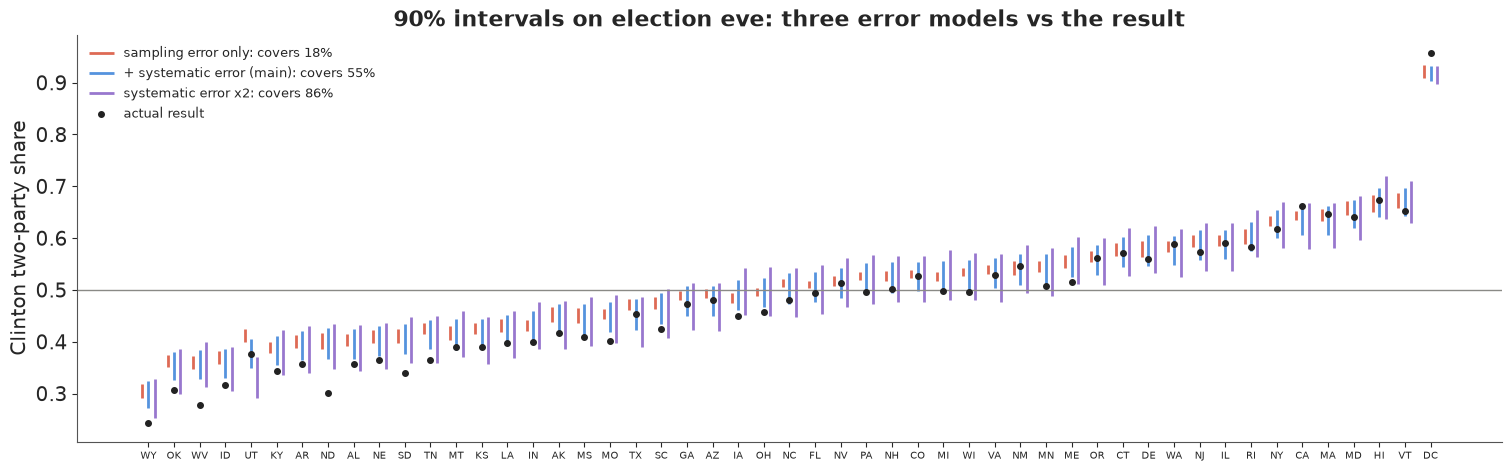

In [22]:
fig, ax = plt.subplots(figsize=(15, 4.6))
cols = {"sampling error only": REP, "+ systematic error (main)": DEM, "systematic error x2": "#7f55c2"}
for j, (label, c) in enumerate(cols.items()):
    lo, hi = np.quantile(ladder[label]["fin"], [0.05, 0.95], axis=0)
    ax.vlines(x + (j - 1) * 0.25, lo[order], hi[order], color=c, lw=2, alpha=0.8,
              label=f"{label}: covers {100 * ladder[label]['90% cover']:.0f}%")
ax.scatter(x, actual[order], color=TRUTH, s=16, zorder=4, label="actual result")
ax.axhline(0.5, color=GREY, lw=1)
ax.set_xticks(x, [STATES[i] for i in order], fontsize=7)
ax.set(ylabel="Clinton two-party share", title="90% intervals on election eve: three error models vs the result")
ax.legend(fontsize=9, loc="upper left");

> **In plain words:** a forecast that only counts the random error of each poll was sure
> Clinton would win, and was wrong about the vote in most states. Allowing for the chance that
> *all* the polls are off in the same direction is what turns "certain" into "likely", and
> even that allowance, set from past elections, was too small for 2016.

## 6 · Explaining it to everyone

**The trouble with "70%".** A win probability is the single most misread number in
journalism. People hear "Clinton 70%" or "Clinton 88%" as "Clinton will win" - or as a vote
share (70% of the vote would be a historic landslide) - and when she loses, the forecast is
declared "wrong". Experiments find that probabilistic forecasts make a race look more
lopsided to readers than a vote-share estimate does, and may even lower turnout (Westwood,
Messing & Lelkes 2020, *Journal of Politics*); forecasters themselves have discussed how the
incentives and the displays interact (Gelman, Hullman, Wlezien & Morris 2020, *Judgment and
Decision Making*). Three rules follow for the displays below: **count, don't percent** ("in 88
of 100 simulated elections"), **show the losing worlds**, not just the average, and **show the
spread** next to any single number. Each display uses only quantities computed above, from the
election-eve model.

### 6.1 100 elections that could happen

One hundred equally likely elections from the forecast (the 1st, 2nd, ... 100th percentiles of
Clinton's electoral votes), each a dot, stacked along the electoral-vote axis and coloured by
the winner - a quantile dotplot (Kay et al. 2016; Fernandes et al. 2018).

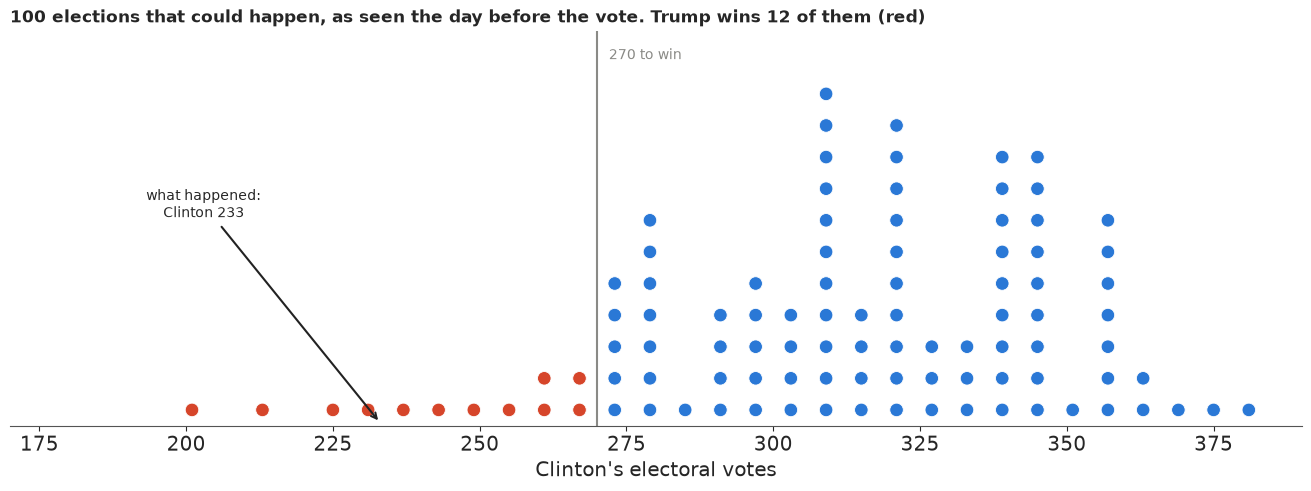

In [23]:
n_dots = 100
ev_q100 = np.quantile(ev_c, (np.arange(n_dots) + 0.5) / n_dots, method="inverted_cdf")
bw = 6                                                   # electoral votes per column of dots
col = (ev_q100 // bw).astype(int)
row = np.zeros(n_dots, int)
for k in range(1, n_dots):
    row[k] = row[k - 1] + 1 if col[k] == col[k - 1] else 0
n_trump = int(np.sum(ev_q100 < 270))
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.scatter(col * bw + bw / 2, row + 0.5, s=95, c=np.where(ev_q100 >= 270, DEM, REP), edgecolor="white", lw=0.6)
top_row = row.max() + 1
ax.axvline(270, color=GREY, lw=1.5)
ax.text(272, top_row + 0.6, "270 to win", fontsize=10, color=GREY)
ax.annotate(f"what happened:\nClinton {actual_ev}", xy=(actual_ev, 0.1), xytext=(actual_ev - 30, top_row * 0.6),
            fontsize=10, ha="center", arrowprops=dict(arrowstyle="->", color=TRUTH, lw=1.5))
ax.set(xlim=(170, 390), ylim=(0, top_row + 1.5), yticks=[], xlabel="Clinton's electoral votes")
for sp in ["left", "right", "top"]:
    ax.spines[sp].set_visible(False)
ax.set_title(f"100 elections that could happen, as seen the day before the vote. Trump wins {n_trump} of them (red)",
             fontsize=12, loc="left");

**Why it works:** the red dots are *there* - a reader can count them and see that a Trump
win was not a freak but a normal member of the family of outcomes, the way a 1-in-10 event is.
It also shows the lumpiness of the electoral college and that the *real* result sat in the
thin left tail. **What it hides:** where the red dots come from (which states flip), and the
fact that the model itself was too confident - the true chance of a result like 2016's was
probably higher than the dots suggest.

### 6.2 A map of plausible elections

A hypothetical-outcome animation (Hullman, Resnick & Adar 2015): every frame is one simulated
election map from the forecast, with its electoral-vote count, and a running tally of who has
won so far. States that flicker are the battlegrounds; the tally teaches the win probability
by accumulation rather than by a number.

In [24]:
TILES = {"AK": (0, 0), "ME": (0, 10), "WI": (1, 5), "VT": (1, 9), "NH": (1, 10),
         "WA": (2, 0), "ID": (2, 1), "MT": (2, 2), "ND": (2, 3), "MN": (2, 4), "IL": (2, 5), "MI": (2, 6),
         "NY": (2, 8), "MA": (2, 9), "OR": (3, 0), "NV": (3, 1), "WY": (3, 2), "SD": (3, 3), "IA": (3, 4),
         "IN": (3, 5), "OH": (3, 6), "PA": (3, 7), "NJ": (3, 8), "CT": (3, 9), "RI": (3, 10),
         "CA": (4, 0), "UT": (4, 1), "CO": (4, 2), "NE": (4, 3), "MO": (4, 4), "KY": (4, 5), "WV": (4, 6),
         "VA": (4, 7), "MD": (4, 8), "DE": (4, 9), "AZ": (5, 1), "NM": (5, 2), "KS": (5, 3), "AR": (5, 4),
         "TN": (5, 5), "NC": (5, 6), "SC": (5, 7), "DC": (5, 8), "OK": (6, 3), "LA": (6, 4), "MS": (6, 5),
         "AL": (6, 6), "GA": (6, 7), "HI": (7, 0), "TX": (7, 3), "FL": (7, 8)}
assert sorted(TILES) == sorted(STATES)
n_frames = 40
frames = rng.choice(len(final), n_frames, replace=False)
fig = plt.figure(figsize=(9, 7.2), dpi=72, layout="none")
ax = fig.add_axes([0.02, 0.2, 0.96, 0.72])
bar_ax = fig.add_axes([0.08, 0.06, 0.84, 0.07])
tiles, labels = {}, {}
for s, (r, c) in TILES.items():
    tiles[s] = ax.add_patch(Rectangle((c, -r), 0.92, 0.92, facecolor=LIGHT, edgecolor="white"))
    labels[s] = ax.text(c + 0.46, -r + 0.58, s, ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    ax.text(c + 0.46, -r + 0.25, str(EV[STATES.index(s)]), ha="center", va="center", fontsize=7, color="white")
ax.set(xlim=(-0.2, 11.2), ylim=(-7.2, 1.1), aspect="equal")
ax.axis("off")
title = ax.set_title("", fontsize=13, loc="left")
bar_ax.set(xlim=(0, n_frames), yticks=[], xticks=[])
bar_ax.set_title("running tally: who won each simulated election so far", fontsize=9, loc="left")
for sp in bar_ax.spines.values():
    sp.set_visible(False)
tally = [bar_ax.add_patch(Rectangle((k, 0), 0.9, 1, facecolor="white", edgecolor=LIGHT)) for k in range(n_frames)]
fig.set_layout_engine("none")
plt.close(fig)


def show_frame(k):
    d = frames[k]
    for i, s in enumerate(STATES):
        close = abs(final[d, i] - 0.5) < 0.03
        tiles[s].set_facecolor(DEM if final[d, i] > 0.5 else REP)
        tiles[s].set_alpha(0.55 if close else 1.0)
    evk = ev_c[d]
    tally[k].set_facecolor(DEM if evk >= 270 else REP)
    for j in range(k + 1, n_frames):
        tally[j].set_facecolor("white")
    wins = int(np.sum(ev_c[frames[: k + 1]] >= 270))
    title.set_text(f"Simulated election {k + 1}: Clinton {evk}, Trump {538 - evk}"
                   f"  -  {'Clinton' if evk >= 270 else 'Trump'} wins\n"
                   f"So far Clinton has won {wins} of {k + 1}  (paler = won by under 3 points)")
    return list(tiles.values()) + tally + [title]


show_frame(0)
hop = animation.FuncAnimation(fig, show_frame, frames=n_frames, interval=700)
print(f"in these {n_frames} frames Clinton wins {int(np.sum(ev_c[frames] >= 270))}; "
      f"over all {len(final):,} simulated elections {c_wins.mean():.1%}")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)     # a constrained-layout warning from the arviz style
    hop_html = hop.to_jshtml(default_mode="once")
HTML(hop_html)

in these 40 frames Clinton wins 38; over all 4,000 simulated elections 87.9%


**Why it works:** each frame is a concrete map a reader recognises, so uncertainty is
experienced as "sometimes the Midwest goes red", and the red frames arrive at the rate the
forecast implies. The paler tiles flag states decided by less than 3 points in that world. A
reader who sees a red Midwest turn up now and then - and the tally count it - learns what
"about 9 in 10" means better than from the number. **What it hides:** a reader who stops on one
frame may take it
for *the* forecast (hence the frame counter and the tally), 40 frames are too few to show rare
outcomes reliably, and it cannot be printed.

### 6.3 An honest needle

A gauge is what people expect from an election-night graphic. This one points at the median
electoral-vote count, but the coloured arc behind it is the message: the dark band is where
half of the simulated elections landed, the pale band nine in ten. The needle is the least
reliable thing on the dial.

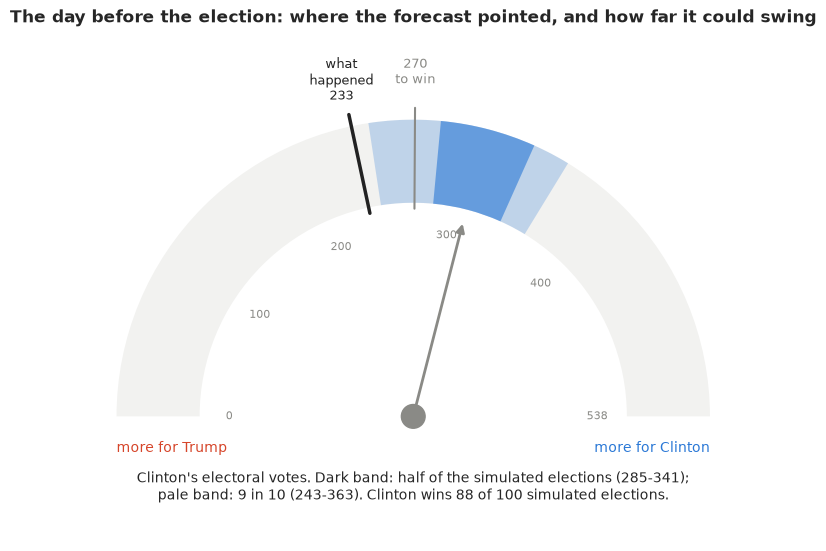

In [25]:
def ev_angle(e):
    return 180 - 180 * e / 538                        # 0 EV at the left (180 deg), 538 at the right (0 deg)


fig, ax = plt.subplots(figsize=(9, 5.4))
ax.add_patch(Wedge((0, 0), 1.0, 0, 180, width=0.28, facecolor="#f2f2f0", edgecolor="none"))
e5, e25, e50, e75, e95 = np.quantile(ev_c, [0.05, 0.25, 0.5, 0.75, 0.95])
ax.add_patch(Wedge((0, 0), 1.0, ev_angle(e95), ev_angle(e5), width=0.28, facecolor=DEM, alpha=0.25, edgecolor="none"))
ax.add_patch(Wedge((0, 0), 1.0, ev_angle(e75), ev_angle(e25), width=0.28, facecolor=DEM, alpha=0.6, edgecolor="none"))
for e, txt in [(270, "270\nto win"), (actual_ev, f"what\nhappened\n{actual_ev}")]:
    a = np.deg2rad(ev_angle(e))
    ax.plot([0.7 * np.cos(a), 1.04 * np.cos(a)], [0.7 * np.sin(a), 1.04 * np.sin(a)], color=TRUTH if e != 270 else GREY,
            lw=2.5 if e != 270 else 1.5)
    ax.text(1.16 * np.cos(a), 1.16 * np.sin(a), txt, ha="center", va="center", fontsize=9,
            color=TRUTH if e != 270 else GREY)
a = np.deg2rad(ev_angle(e50))
ax.annotate("", xy=(0.68 * np.cos(a), 0.68 * np.sin(a)), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=GREY, lw=2))
ax.add_patch(Circle((0, 0), 0.04, color=GREY))
for e in [0, 100, 200, 300, 400, 538]:
    a = np.deg2rad(ev_angle(e))
    ax.text(0.62 * np.cos(a), 0.62 * np.sin(a), str(e), ha="center", va="center", fontsize=8, color=GREY)
ax.text(-1.0, -0.12, "more for Trump", color=REP, fontsize=10, ha="left")
ax.text(1.0, -0.12, "more for Clinton", color=DEM, fontsize=10, ha="right")
ax.text(0, -0.28, f"Clinton's electoral votes. Dark band: half of the simulated elections ({e25:.0f}-{e75:.0f});\n"
        f"pale band: 9 in 10 ({e5:.0f}-{e95:.0f}). Clinton wins {100 * c_wins.mean():.0f} of 100 simulated elections.",
        ha="center", fontsize=10)
ax.set(xlim=(-1.3, 1.3), ylim=(-0.42, 1.3), aspect="equal")
ax.axis("off")
ax.set_title("The day before the election: where the forecast pointed, and how far it could swing", fontsize=12);

**Why it works:** it borrows a familiar object and subverts the false precision of a single
needle; the band's width is visible at a glance, and "what happened" sits on the same dial,
just outside the pale band - the honest verdict on this forecast. **What it hides:** the
distribution inside the bands (the electoral college is lumpy, not smooth), and the reason
for the width.

### 6.4 A map you can ask questions of

An interactive map (plotly): colour is Clinton's chance of carrying each state, in the same
"out of 100" language, with a diverging scale that is white at a coin flip. Hovering gives a
plain-language card with the likely range of her vote share and, since we know it now, what
happened.

In [26]:
lo90, hi90 = np.quantile(final, [0.05, 0.95], axis=0)
hover = [f"<b>{STATE_NAMES[s]}</b> ({EV[i]} electoral votes)<br>"
         f"Clinton wins in {100 * p_state[i]:.0f} of 100 simulated elections<br>"
         f"her likely share of the two-party vote: {100 * lo90[i]:.0f}% to {100 * hi90[i]:.0f}%<br>"
         f"what happened: {100 * actual[i]:.1f}% - {'Clinton' if actual[i] > 0.5 else 'Trump'} won"
         f"{' <i>(outside the likely range)</i>' if not lo90[i] <= actual[i] <= hi90[i] else ''}"
         for i, s in enumerate(STATES)]
fig = go.Figure(go.Choropleth(
    locations=STATES, locationmode="USA-states", z=100 * p_state, zmin=0, zmax=100,
    colorscale=[[0, REP], [0.5, "#f7f7f7"], [1, DEM]], text=hover, hoverinfo="text",
    marker_line_color="white", colorbar=dict(title="Clinton wins<br>in N of 100", ticksuffix="")))
fig.update_layout(title="Election eve 2016: Clinton's chance in each state (hover for details)",
                  geo=dict(scope="usa"), width=820, height=500, margin=dict(l=10, r=10, t=50, b=10))
fig.show()
print("hover example:", hover[STATES.index("WI")].replace("<br>", " | "))

hover example: <b>Wisconsin</b> (10 electoral votes) | Clinton wins in 95 of 100 simulated elections | her likely share of the two-party vote: 50% to 56% | what happened: 49.6% - Trump won <i>(outside the likely range)</i>


**Why it works:** a reader explores at their own pace and gets every number with a sentence
attached; the pale states are the ones to watch, and the hover card puts the forecast and the
outcome side by side. **What it hides:** the map is a set of *separate* state chances - it
cannot show that Wisconsin, Michigan and Pennsylvania tend to fall together, which is exactly
what decided 2016 (the animation in 6.2 does show it). Large, empty states dominate the eye.

## 7 · Export for the web page

In [27]:
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
keep = rng.choice(len(final), 300, replace=False)
HEADLINES = {
    "win_probability": (f"The day before the 2016 election the model gave Clinton {100 * c_wins.mean():.0f} chances in 100: "
                        f"Trump won in about {100 - round(100 * c_wins.mean())} of every 100 simulated elections, and "
                        f"then won the real one."),
    "electoral_votes": (f"Clinton's likely electoral-vote range was {e5:.0f} to {e95:.0f} (9 in 10 simulated elections); "
                        f"she got {actual_ev}."),
    "timeline": (f"All summer the forecast gave Clinton about {100 * timeline[1]['p_clinton']:.0f} in 100; it rose to "
                 f"{100 * timeline[-1]['p_clinton']:.0f} in 100 by election eve."),
    "polling_error": (f"Counting only the random error of each poll, Clinton wins "
                      f"{100 * ladder['sampling error only']['P(Clinton)']:.0f} in 100 and the 'likely ranges' contain the "
                      f"result in {100 * ladder['sampling error only']['90% cover']:.0f}% of states; allowing for polls "
                      f"that are all wrong together gives {100 * c_wins.mean():.0f} in 100 and "
                      f"{100 * cover90:.0f}%."),
    "tipping_point": (f"The likeliest decisive states were {STATE_NAMES[tip_p.index[0]]} and {STATE_NAMES[tip_p.index[1]]}; "
                      f"the state that actually decided it was {STATE_NAMES[STATES[actual_tip[0]]]}."),
}
export = {
    "id": "E40",
    "title": "Who will win? Forecasting the 2016 US presidential election from the polls",
    "units": {"share": "Clinton share of the two-party (Clinton + Trump) vote, 0-1",
              "ev": "Clinton electoral votes out of 538 (270 to win; Maine and Nebraska winner-take-all)"},
    "forecast_date": "2016-11-07",
    "p_clinton_win": round(float(c_wins.mean()), 3),
    "ev_draws": ev_c[keep].astype(int).tolist(),
    "ev_quantiles_100": ev_q100.astype(int).tolist(),
    "national_share_draws": np.round(nat_final[keep], 4).tolist(),
    "actual": {"ev_clinton": actual_ev, "national_share": round(float(np.dot(actual, W)), 4),
               "tipping_point": STATES[actual_tip[0]]},
    "states": [{
        "abbr": s, "name": STATE_NAMES[s], "ev": int(EV[i]), "tile_row": TILES[s][0], "tile_col": TILES[s][1],
        "p_clinton": round(float(p_state[i]), 3), "p_tipping_point": round(float(tip_p[s]), 3),
        "q05": round(float(q05[i]), 4), "q25": round(float(q25[i]), 4), "median": round(float(q50[i]), 4),
        "q75": round(float(q75[i]), 4), "q95": round(float(q95[i]), 4), "actual": round(float(actual[i]), 4),
        "n_polls": int((eve.state == s).sum()),
    } for i, s in enumerate(STATES)],
    "map_draws": np.round(final[keep[:60]], 3).tolist(),     # 60 joint simulated elections (draw x state, STATES order)
    "state_order": STATES,
    "national_path": {"week_end": [str(d.date()) for d in WEEK_END],
                      "q05": np.round(np.quantile(nat_path, 0.05, axis=0), 4).tolist(),
                      "median": np.round(np.median(nat_path, axis=0), 4).tolist(),
                      "q95": np.round(np.quantile(nat_path, 0.95, axis=0), 4).tolist()},
    "timeline": [{"as_of": str(t["as_of"].date()), "p_clinton": round(float(t["p_clinton"]), 3),
                  "ev_q05": int(t["ev_q"][0]), "ev_q25": int(t["ev_q"][1]), "ev_median": int(t["ev_q"][2]),
                  "ev_q75": int(t["ev_q"][3]), "ev_q95": int(t["ev_q"][4]), "state_cover90": round(float(t["cover90"]), 3)}
                 for t in timeline],
    "error_models": [{"model": k, "p_clinton": round(float(d["P(Clinton)"]), 3), "state_cover90": round(float(d["90% cover"]), 3),
                      "state_cover50": round(float(d["50% cover"]), 3)} for k, d in ladder.items()],
    "headlines": HEADLINES,
}
out = root / ".scratch" / "artifact" / "E40.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":")))
print(f"wrote {out.relative_to(root)} ({out.stat().st_size / 1024:.0f} KB)")
for v in HEADLINES.values():
    print("-", v)

wrote .scratch/artifact/E40.json (35 KB)
- The day before the 2016 election the model gave Clinton 88 chances in 100: Trump won in about 12 of every 100 simulated elections, and then won the real one.
- Clinton's likely electoral-vote range was 243 to 363 (9 in 10 simulated elections); she got 233.
- All summer the forecast gave Clinton about 71 in 100; it rose to 88 in 100 by election eve.
- Counting only the random error of each poll, Clinton wins 100 in 100 and the 'likely ranges' contain the result in 18% of states; allowing for polls that are all wrong together gives 88 in 100 and 55%.
- The likeliest decisive states were Pennsylvania and Florida; the state that actually decided it was Wisconsin.


The page export above keeps a few hundred draws. The interactive Lumen reports in `reports/`
use the **full posterior** instead: every chain and draw of the fitted parameters, plus the
quantities derived from them over all the draws they were computed on
(`reports/posteriors/E40.nc`, see `reports/README.md`).

In [28]:
from pymc_challenges.export import save_posterior

save_posterior("E40", idata, {
    "clinton_state_share": (("sample", "state"), final, {"state": [STATE_NAMES[s] for s in STATES]}, "share 0-1",
                            "Clinton two-party share per state on election day; draws are joint across states"),
    "clinton_electoral_votes": (("sample",), ev_c, {}, "electoral votes", "Clinton's electoral votes out of 538 (270 wins)"),
    "clinton_national_share": (("sample",), nat_final, {}, "share 0-1", "Clinton share of the national two-party vote"),
});

wrote reports/posteriors/E40.nc: 12 parameters x 4000 draws; 3 derived quantities; 66.3 MB


## What to take away

- **A dynamic forecast is a prior plus a filter.** The fundamentals anchor election day, the
  reverse random walk carries the polls forward to it, and the state-similarity matrix lets
  a poll in Michigan inform Wisconsin. Weekly steps and a normal approximation on the logit
  scale keep it at about 20 seconds per fit in PyMC.
- **Adjusting the polls (house, mode, population) makes them consistent, not right.** The
  posterior predictive check in poll space passes, and says nothing about the one error that
  mattered.
- **The systematic, correlated polling error is the whole game** for the win probability. It
  cannot be learned from one cycle's polls, so it is set from past elections; leaving it out
  gives the "99%" forecasts of 2016. Rotating the non-identified pair (truth, polling error)
  made it easy to sample.
- **Score forecasts on what they said at the time**, with coverage and a joint check - 51
  states are not 51 independent tests when their errors are correlated.
- **Communicate in counts and in worlds**: "Trump wins in about 12 of 100 simulated elections",
  with the losing worlds on screen.

## Try it yourself

1. **Learn the systematic error from history.** The same repository has the 2008 and 2012
   polls (`all_polls_2008.csv`, `all_polls_2012.csv`) and results. Fit the model to each of
   them, compute the state-level errors of the election-eve forecasts, and set the scale of
   $\beta$ from their spread - would that have been larger or smaller than 1.3 points?
2. **Partisan non-response.** The Economist adds a day-varying AR(1) term that shifts all
   polls from pollsters that do *not* weight by party (their `e_bias`). Add it on the weekly
   grid (the list of weighting pollsters is in the R script) and see whether it absorbs part
   of the swings around the conventions and the *Access Hollywood* tape.
3. **No correlation.** Replace $\Sigma$ with a diagonal matrix of the same state variances (so
   states move and miss independently). Recompute the win probability and the joint
   calibration percentile: how much of the 2016 surprise was about correlation rather than
   the size of the error?